# Airbnb Price Prediction & Explainability - London

Combined notebook: descriptive analysis, inferential statistics (OLS), comparison of five
machine-learning models via **k-fold cross-validation**, and explainable AI (XAI: SHAP, PDP, ICE).

**Data:** Inside Airbnb, London, snapshot of September 16, 2025 (`data.csv`). Package versions: `requirements.txt`.

**Outline:**
1. Data preparation & feature engineering
2. Descriptive statistics
3. Hypothesis test (Superhost price premium)
4. Linear regression (OLS inference, k−1 coding)
5. Machine-learning comparison (5 models, 5-fold cross-validation)
6. Explainable AI (SHAP, PDP, ICE)
7. Critical evaluation
8. Conclusion


In [1]:
# Load libraries
import pandas as pd
import numpy as np
import ast
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import statsmodels.api as sm
from scipy import stats
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score, median_absolute_error
from sklearn.linear_model import RidgeCV
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.inspection import PartialDependenceDisplay
import xgboost as xgb
import shap
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Suppress known, result-neutral library warnings (clean output):
#  - sklearn reports a feature-name inconsistency for eval_set (cosmetic)
#  - matplotlib note for subplots without labelled legend artists
import warnings
warnings.filterwarnings('ignore', message='X does not have valid feature names')
warnings.filterwarnings('ignore', message='No artists with labels')

# Plot styling: black text on white background (print/PDF friendly)
RC_PLOT = {
    'text.color':      'black',
    'axes.labelcolor': 'black',
    'xtick.color':     'black',
    'ytick.color':     'black',
}


## 1. Data preparation

The raw dataset contains 79 columns and 96,871 Airbnb listings in London. This section turns it into a dataset ready for modelling.

**Data source:** Inside Airbnb (https://insideairbnb.com), city of London, publicly available snapshot of **September 16, 2025** (field `last_scraped`). The data are collected by web-scraping the public Airbnb pages and are **not** provided by Airbnb itself. Fields such as `price`, `availability_365` or the `review_scores_*` therefore reflect what hosts *display* at collection time - not necessarily realised bookings or transaction prices. From the 79 raw columns, 16 substantively justified features are selected (see the column comments in the next cell); heavily incomplete, free-text-only, or redundant fields are excluded. This selection is a deliberate modelling decision and should be read in the context of the target variable (nightly price).

The main steps and their justification:

| Step | Why? |
|---|---|
| **Feature selection** (16 of 79 columns) | Redundant columns such as `beds` (correlation 0.80 with `accommodates`) and `review_scores_rating` (weaker signal than `review_scores_location`) are removed to reduce multicollinearity |
| **Remove missing values** | Listwise deletion (`dropna`) - **~52% of rows affected** (96,871 -> 46,750), mainly missing `price` (36%), `bathrooms` (36%) and `review_scores_location` (25%); no imputation. -> **Strong sample bias** towards fully documented, reviewed listings |
| **Categorical encoding** | `neighbourhood_cleansed` -> 33 dummy variables; `room_type` -> binary flags. For the *inferential* OLS estimation (Section 4), one reference category is dropped per categorical variable (**k−1 coding**) to avoid the dummy-variable trap (perfect collinearity with the constant) |
| **Coordinates -> distance** | Latitude/longitude are converted with the Haversine formula into a single interpretable number: straight-line distance to the London centre in metres |
| **Outlier removal** (empirically justified) | Price **< $10** = sanity floor against placeholder/erroneous prices (affects 0 listings, merely documents the assumption); price **≥ $1,000/night** = top ~0.8% of listings, above the 99th percentile (≈ $907) and reaching up to $74,100/night -> implausible extreme/erroneous values that would dominate RMSE and error dispersion; bedrooms > 10 (2 listings); bathrooms > 8 (4 listings); `availability_365 = 0` (calendar never bookable during the collection window) |
| **Amenity extraction** | The raw text list `amenities` is decomposed into `amenity_count` and 4 binary flags; quasi-constant features (`has_wifi` 98.3%, `has_kitchen` 91.5%) are excluded; listings without any amenity information (`amenity_count = 0`, 12 listings) are removed |


In [2]:
# Constants
file_path = 'data.csv'
columns = [
    # 'id', 'name',

    # Host
    'host_is_superhost',              # Experienced, highly rated host - may command a price premium

    # Location (converted into distance to the centre later)
    'latitude', 'longitude',          # Raw coordinates -> converted into straight-line distance to the city centre

    # Accommodation type & size
    'room_type',                      # Entire home vs. private room - strongest categorical price driver
    'accommodates',                   # Maximum number of guests - most important size signal and price driver
    'bathrooms',                      # More bathrooms = larger, higher-quality property
    'bathrooms_text',                 # Raw text used to distinguish shared vs. private bathroom
    'bedrooms',                       # Number of bedrooms - complements accommodates for size
    # 'beds'deliberately excluded - correlation 0.805 with accommodates (redundant)

    # Amenities
    'amenities',                      # Raw text list -> converted into amenity_count and binary has_* flags

    # Target variable
    'price',                          # Nightly price in USD - the variable we want to predict

    # Quality and demand signals
    'review_scores_location',         # Guest-rated location (1–5); captures perceived attractiveness
                                      # beyond the borough. Stronger signal than review_scores_rating
                                      # (corr. +0.132 vs. +0.032 with the price).
    'availability_365',               # Days bookable per year. CAUTION when reading this as a demand/
                                      # quality signal: Inside Airbnb only measures the calendar status,
                                      # not the reason. A low value can mean personal use, manual blocking,
                                      # or seasonal closure - not necessarily high demand/occupancy.

    # Geography
    'neighbourhood_cleansed',         # Standardised London borough -> recoded into 33 binary columns

    # Host professionalism
    'calculated_host_listings_count', # Number of active listings of this host - separates professional
                                      # operators (many listings, strategic pricing) from private hosts.

    # Demand & host profile
    'estimated_occupancy_l365d',      # Estimated occupancy days per year - direct demand information
    'host_has_profile_pic',           # Trust signal: hosts with a profile picture tend to obtain higher prices
]
# Source: https://www.latlong.net/place/london-uk-14153.html
london_center_lat = 51.509865
london_center_lon = -0.118092


In [3]:
# Read the raw dataset
df = pd.read_csv(file_path)

In [4]:
# Keep only the relevant columns and drop rows with missing values
df = df[columns].dropna()

In [5]:
# Explore the borough column before encoding
print(df['neighbourhood_cleansed'].nunique())             # How many unique boroughs?
print(df['neighbourhood_cleansed'].value_counts().head(10))

33
neighbourhood_cleansed
Westminster               6239
Kensington and Chelsea    3505
Camden                    3419
Tower Hamlets             3284
Hackney                   2520
Southwark                 2412
Wandsworth                2336
Lambeth                   2244
Islington                 2179
Hammersmith and Fulham    2097
Name: count, dtype: int64


In [6]:
# One-hot encoding of the borough column:
# each borough gets its own 0/1 column (e.g. nb_Westminster = 1 if the listing is located there).
nb_dummies = pd.get_dummies(df['neighbourhood_cleansed'], prefix='nb', dtype=int)
df = pd.concat([df, nb_dummies], axis=1)
df = df.drop(columns='neighbourhood_cleansed')

In [7]:
def calculate_haversine_distance(lat_series, lon_series, center_lat, center_lon):
    """
    Computes the straight-line distance (in metres) between each listing and a fixed point.

    Uses the Haversine formula, which correctly accounts for the curvature of the earth.
    The function is vectorised - it processes the whole column at once (very fast).
    """
    R = 6371000.0  # earth radius in metres

    # Convert degrees to radians (required for the trigonometric functions)
    phi1         = np.radians(lat_series)
    phi2         = np.radians(center_lat)
    delta_phi    = np.radians(center_lat - lat_series)
    delta_lambda = np.radians(center_lon - lon_series)

    # Haversine formula
    a = np.sin(delta_phi / 2.0)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(delta_lambda / 2.0)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

    return R * c

In [8]:
# Keep the coordinates for the geographic visualisation later
_geo_lat = df['latitude'].copy()
_geo_lon = df['longitude'].copy()

# Replace the raw coordinates by the distance feature (metres to the city centre)
df['distance_to_center_m'] = calculate_haversine_distance(
    df['latitude'], df['longitude'],
    london_center_lat, london_center_lon
).round()

df = df.drop(columns=['latitude', 'longitude'])

In [9]:
# Convert text values 't'/'f'into 0/1
df['host_is_superhost']  = (df['host_is_superhost']  == 't').astype(int)
df['host_has_profile_pic'] = (df['host_has_profile_pic'] == 't').astype(int)

# is_professional_host: hosts with >= 10 active listings are considered professional
df['is_professional_host'] = (df['calculated_host_listings_count'] >= 10).astype(int)
print(f"Professional hosts:   {df['is_professional_host'].sum():,}  "
      f"({df['is_professional_host'].mean()*100:.1f}% of listings)")
print(f"Profile picture:      {df['host_has_profile_pic'].sum():,}  "
      f"({df['host_has_profile_pic'].mean()*100:.1f}%)")
print(f"Occupancy (mean):     {df['estimated_occupancy_l365d'].mean():.1f} days/year")

Professional hosts:   13,713  (29.3% of listings)
Profile picture:      44,973  (96.2%)
Occupancy (mean):     81.4 days/year


In [10]:
# Recode the room type into four separate 0/1 columns (one-hot encoding)
print(df['room_type'].unique())
df["is_private_room"] = (df["room_type"] == "Private room").astype(int)
df["is_entire_home"]  = (df["room_type"] == "Entire home/apt").astype(int)
df["is_hotel_room"]   = (df["room_type"] == "Hotel room").astype(int)
df["is_shared_room"]  = (df["room_type"] == "Shared room").astype(int)

df = df.drop(columns=['room_type'])

<ArrowStringArray>
['Private room', 'Entire home/apt', 'Hotel room', 'Shared room']
Length: 4, dtype: str


In [11]:
# Remove rare room types - hotel rooms (41 listings) and shared rooms (111 listings)
# are too few to learn reliable patterns from.
df = df[(df['is_hotel_room'] == False) & (df['is_shared_room'] == False)]
df = df.drop(columns=['is_hotel_room', 'is_shared_room', 'is_private_room'])  # is_private_room redundant (= 1 − is_entire_home) -> unambiguous room-type coding

In [12]:
# Clean the price column: remove '$'and ','characters, then convert to float
df['price_dollar'] = (df['price']
                      .str.replace("$", "", regex=False)
                      .str.replace(",", "", regex=False)
                      .str.replace(".00", "", regex=False)
                      .astype(float))
df = df.drop(columns=['price'])

In [13]:
# Create a 1/0 flag: 1 = shared bathroom, 0 = private bathroom
df['is_shared_bath'] = df['bathrooms_text'].str.contains('shared', case=False, na=False).astype(int)
df = df.drop(columns='bathrooms_text')

In [14]:
# Remove outliers
n0 = len(df)

# Price outliers - empirically justified bounds (snapshot September 16, 2025):
#   Lower bound $10:    sanity floor against placeholder/erroneous prices. Affects 0 listings
#                       in this dataset - merely documents the assumption.
#   Upper bound $1,000: top ~0.8% of listings (99th percentile ≈ $907); the right tail
#                       reaches up to $74,100/night. Such values are implausible for regular
#                       London Airbnbs (typos, monthly instead of nightly rates, luxury
#                       special cases) and would dominate RMSE and error dispersion.
df = df[(df['price_dollar'] >= 10) & (df['price_dollar'] < 1000)]

# Bedrooms > 10: only 2 listings, implausible for Airbnb
df = df[df['bedrooms'] <= 10]

# Bathrooms > 8: only 4 listings, implausible
df = df[df['bathrooms'] <= 8]

# availability_365 == 0: calendar never bookable during the collection window -> no
# market-relevant nightly price. Note: > 0 means "bookable", not necessarily "in demand".
df = df[df['availability_365'] > 0]

print(f'Listings removed in total: {n0 - len(df):,}  ->  {len(df):,} remaining')

Listings removed in total: 978  ->  45,620 remaining


In [15]:
# Amenity feature extraction
#
# The raw amenities column is a text that looks like a Python list:
#   '["Wifi", "Kitchen", "Private pool", ...]'
#
# Two kinds of features are derived from it:
#   1. amenity_count  - total number of amenities (more = higher-quality listing)
#   2. has_*          - binary flag for relevant individual amenities
#
# has_wifi (98.3%) and has_kitchen (91.5%) were removed  - 
# quasi-constant features carry almost no information and waste model capacity.

def parse_amenities(val):
    """Convert the amenities text into a Python list."""
    if isinstance(val, list):
        return val
    if isinstance(val, str):
        try:
            return ast.literal_eval(val)
        except (ValueError, SyntaxError):
            return []
    return []

amenities_lists = df['amenities'].apply(parse_amenities)

# Total number of amenities per listing
df['amenity_count'] = amenities_lists.apply(len)

# Targeted binary flags - case-insensitive to capture variants such as
# "Private pool", "Patio or balcony" or "Hot tub/Jacuzzi".
targeted_amenities = {
    'has_pool':    lambda lst: any('pool'in a.lower() for a in lst),
    'has_hot_tub': lambda lst: any('hot tub'in a.lower() or 'jacuzzi'in a.lower() for a in lst),
    'has_bathtub': lambda lst: any('bathtub'in a.lower() for a in lst),
    'has_balcony': lambda lst: any('balcony'in a.lower() or 'patio'in a.lower() for a in lst),
}

for col, check in targeted_amenities.items():
    df[col] = amenities_lists.apply(check).astype(int)
    n = df[col].sum()
    print(f"{col:<15} {n:>6,} listings  ({n / len(df) * 100:.1f}%)")

print(f"\namenity_count:  mean={df['amenity_count'].mean():.1f}  "
      f"min={df['amenity_count'].min()}  max={df['amenity_count'].max()}")

# Drop the raw text column - all information has been extracted
df = df.drop(columns='amenities')

# Remove listings without any amenity information - amenity_count == 0
# indicates missing or faulty data, not genuinely empty amenities.
n_before = len(df)
df = df[df['amenity_count'] > 0]
print(f"\nListings without amenity information removed: {n_before - len(df):,}  ->  {len(df):,} remaining")

has_pool           533 listings  (1.2%)
has_hot_tub        844 listings  (1.9%)
has_bathtub     20,952 listings  (45.9%)


has_balcony     11,450 listings  (25.1%)

amenity_count:  mean=33.4  min=0  max=96

Listings without amenity information removed: 12  ->  45,608 remaining


## 2. Descriptive statistics

Overview of the distribution of the nightly price and the most important features. Histograms, a geographic map, and scatter plots help identify patterns and relationships in the dataset. Finally, the correlation structure of all features is analysed.


In [16]:
summary_cols = [
    'price_dollar', 'accommodates', 'bedrooms', 'bathrooms',
    'distance_to_center_m', 'review_scores_location',
    'availability_365', 'calculated_host_listings_count', 'amenity_count',
]
print("Descriptive statistics - selected features\n")
display(df[summary_cols].describe().round(2))

Descriptive statistics - selected features



,price_dollar,accommodates,bedrooms,bathrooms,distance_to_center_m,review_scores_location,availability_365,calculated_host_listings_count,amenity_count
count,45608.00,45608.00,45608.00,45608.00,45608.00,45608.00,45608.00,45608.00,45608.00
mean,164.48,3.50,1.52,1.33,7540.94,4.72,206.03,16.00,33.39
std,130.96,2.12,0.94,0.61,4931.28,0.42,118.83,40.28,14.01
min,10.00,1.00,0.00,0.00,59.00,1.00,1.00,1.00,1.00
25%,75.00,2.00,1.00,1.00,3860.00,4.64,89.00,1.00,23.00
50%,130.00,3.00,1.00,1.00,6293.00,4.83,225.00,3.00,34.00
75%,206.25,4.00,2.00,1.50,10052.00,5.00,321.00,13.00,43.00
max,999.00,16.00,10.00,8.00,29135.00,5.00,365.00,500.00,96.00


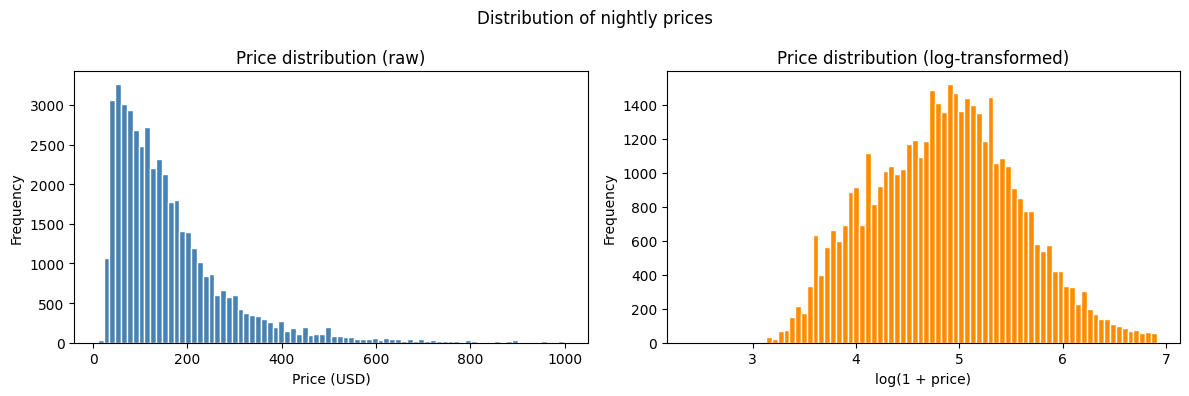

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['price_dollar'], bins=80, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Price (USD)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Price distribution (raw)')

axes[1].hist(np.log1p(df['price_dollar']), bins=80, color='darkorange', edgecolor='white')
axes[1].set_xlabel('log(1 + price)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Price distribution (log-transformed)')

plt.suptitle('Distribution of nightly prices')
plt.tight_layout()
plt.show()

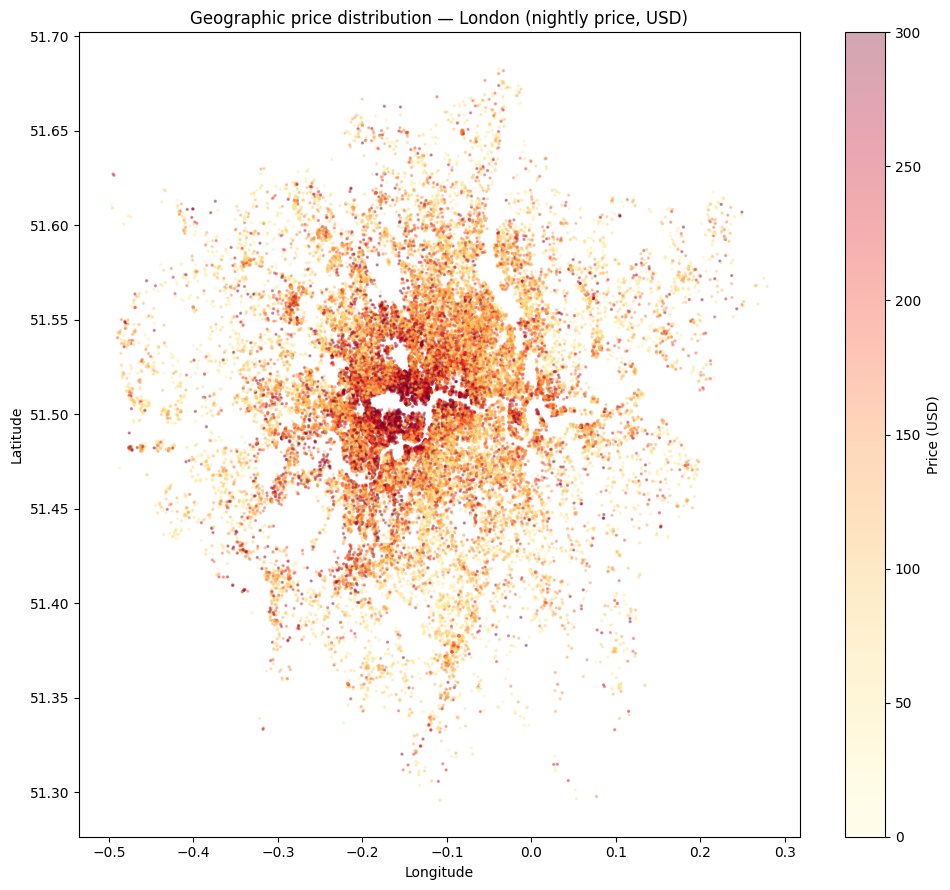

In [18]:
fig, ax = plt.subplots(figsize=(10, 9))
sc = ax.scatter(
    _geo_lon.loc[df.index], _geo_lat.loc[df.index],
    c=df['price_dollar'], cmap='YlOrRd',
    alpha=0.35, s=2, vmin=0, vmax=300,
)
plt.colorbar(sc, ax=ax, label='Price (USD)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Geographic price distribution — London (nightly price, USD)')
plt.tight_layout()
plt.show()

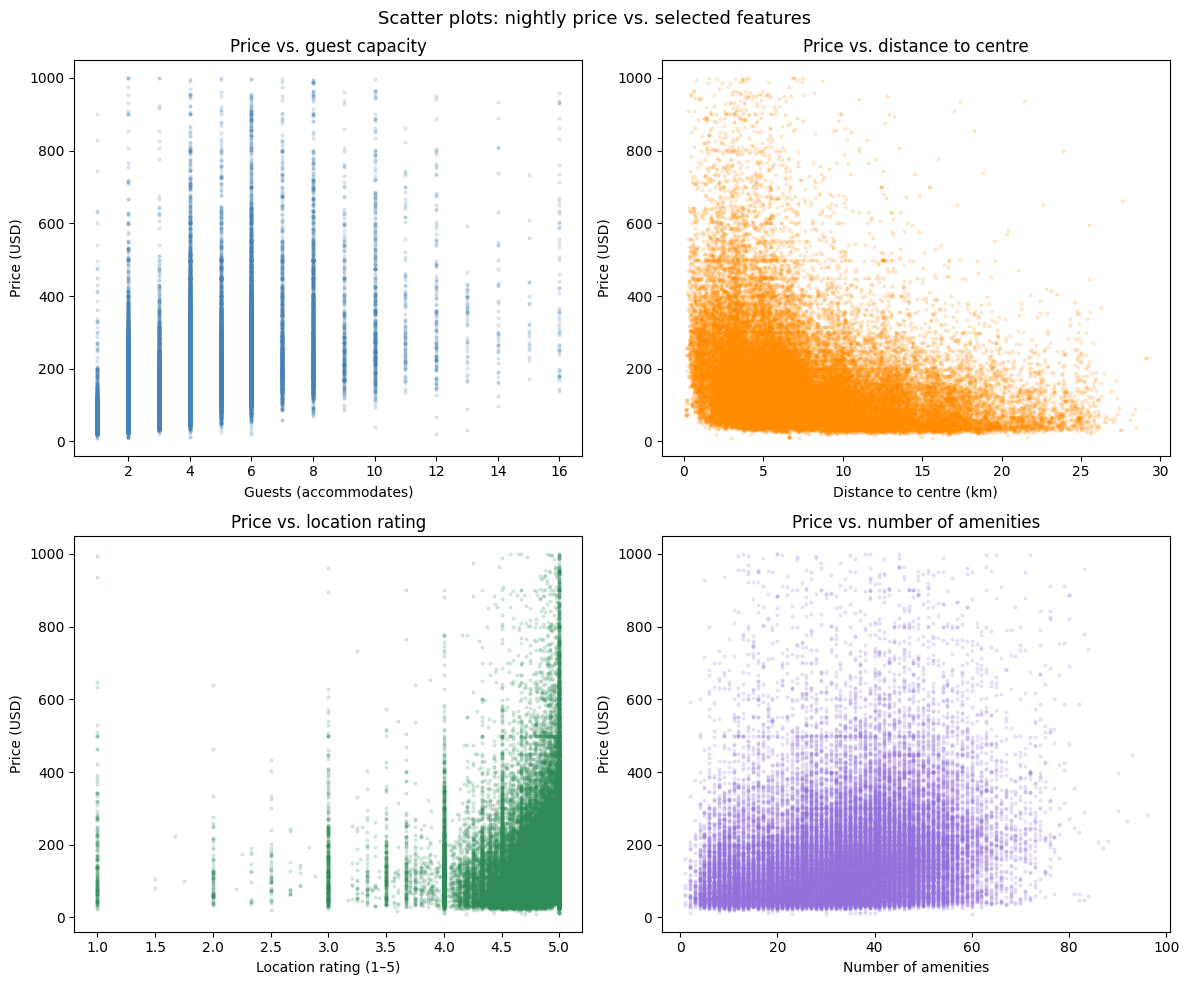

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].scatter(df['accommodates'], df['price_dollar'], alpha=0.15, s=4, color='steelblue')
axes[0, 0].set_xlabel('Guests (accommodates)')
axes[0, 0].set_ylabel('Price (USD)')
axes[0, 0].set_title('Price vs. guest capacity')

axes[0, 1].scatter(df['distance_to_center_m'] / 1000, df['price_dollar'], alpha=0.15, s=4, color='darkorange')
axes[0, 1].set_xlabel('Distance to centre (km)')
axes[0, 1].set_ylabel('Price (USD)')
axes[0, 1].set_title('Price vs. distance to centre')

axes[1, 0].scatter(df['review_scores_location'], df['price_dollar'], alpha=0.15, s=4, color='seagreen')
axes[1, 0].set_xlabel('Location rating (1–5)')
axes[1, 0].set_ylabel('Price (USD)')
axes[1, 0].set_title('Price vs. location rating')

axes[1, 1].scatter(df['amenity_count'], df['price_dollar'], alpha=0.15, s=4, color='mediumpurple')
axes[1, 1].set_xlabel('Number of amenities')
axes[1, 1].set_ylabel('Price (USD)')
axes[1, 1].set_title('Price vs. number of amenities')

plt.suptitle('Scatter plots: nightly price vs. selected features', fontsize=13)
plt.tight_layout()
plt.show()

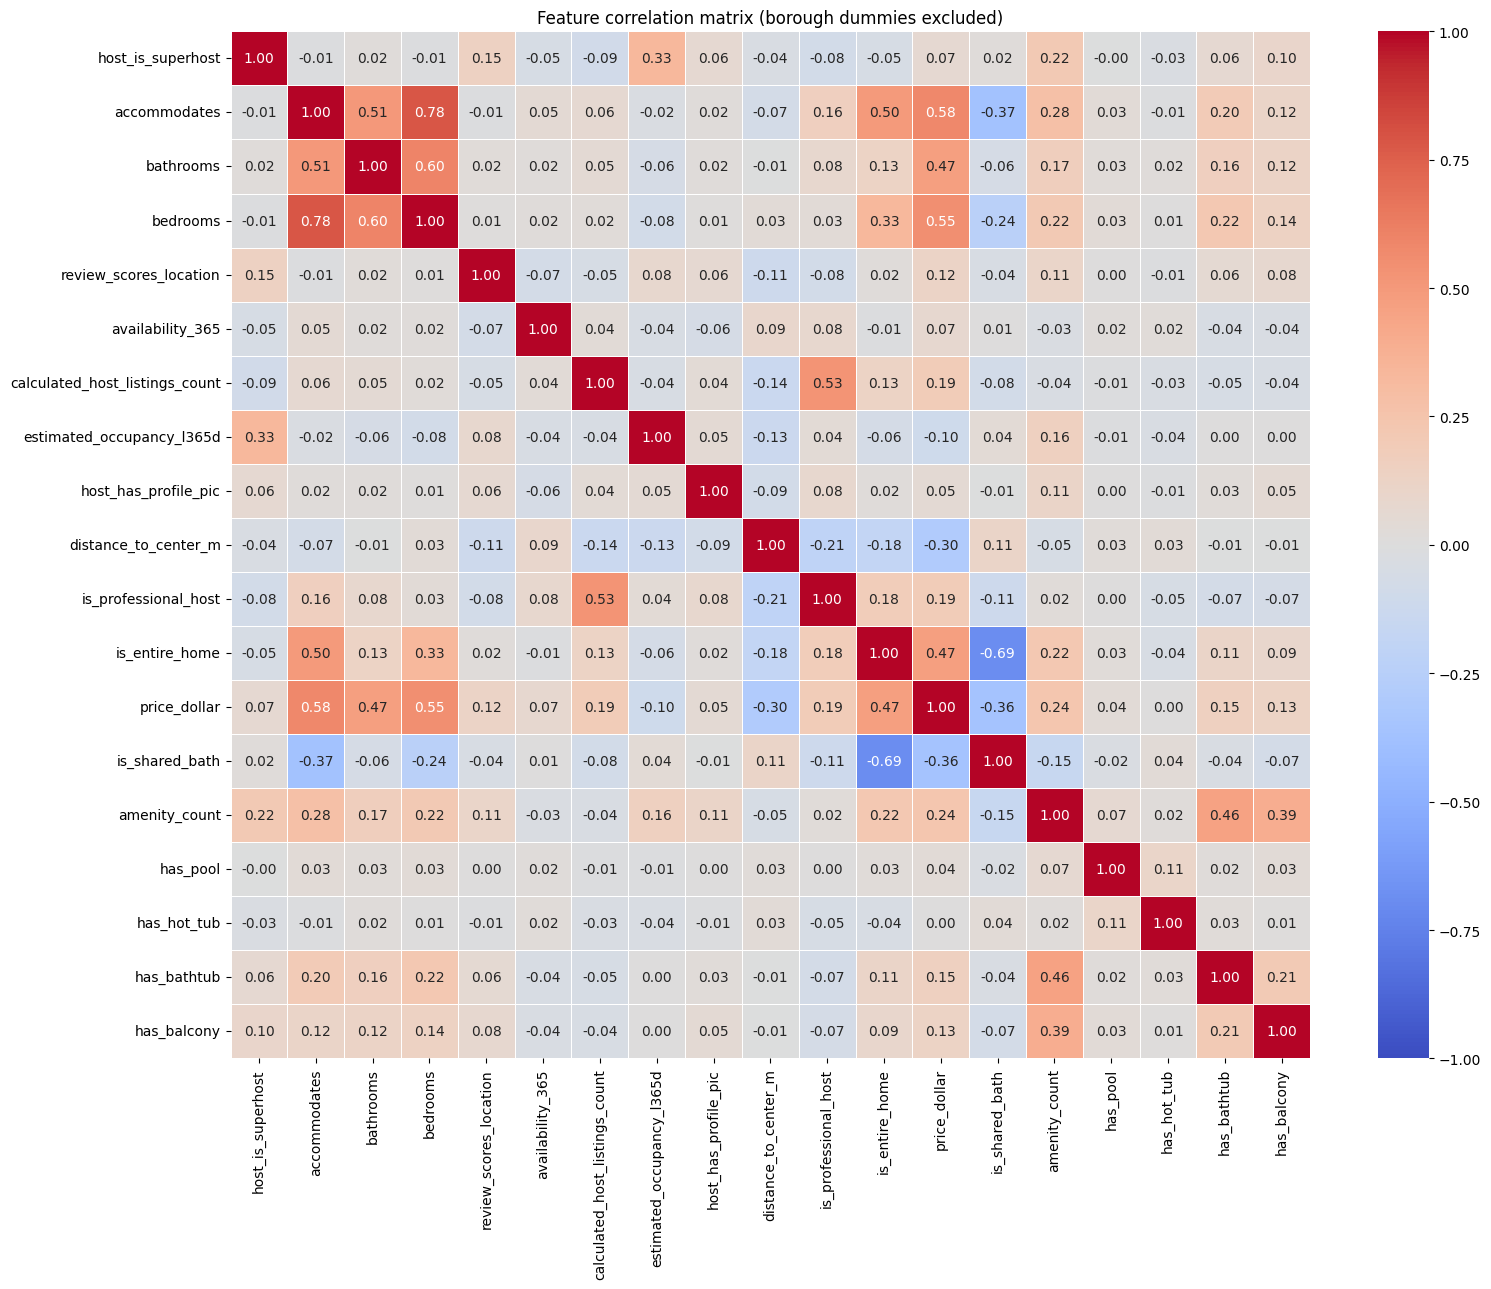

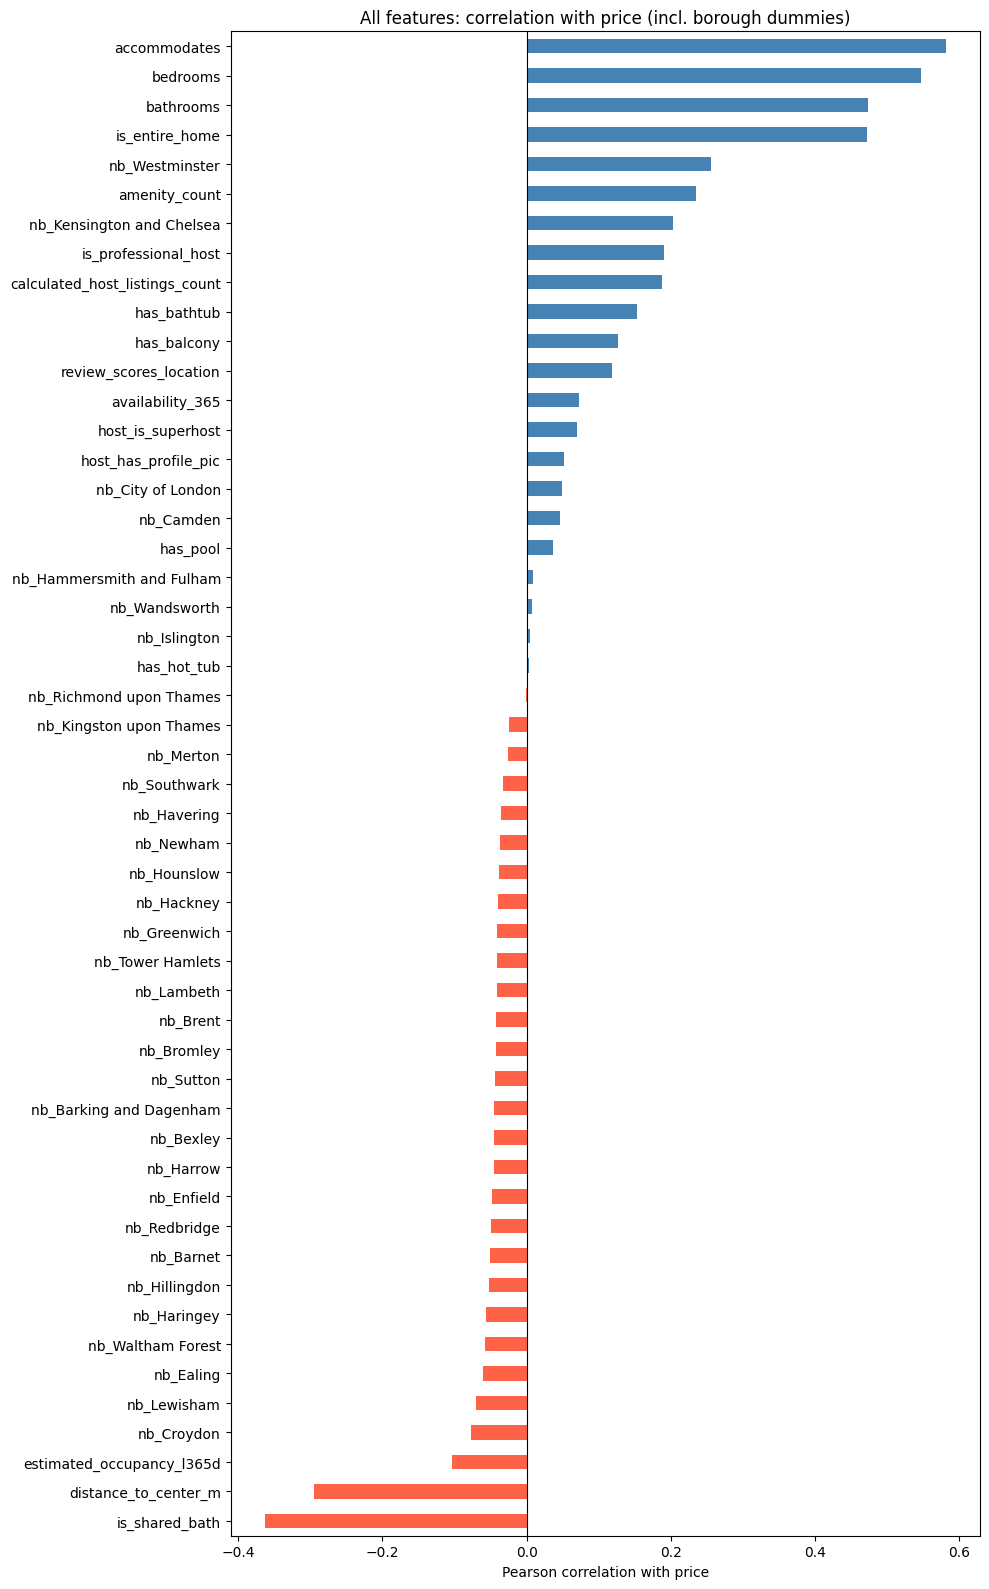

In [20]:
# Feature correlation analysis
#
# Chart 1 - heatmap of all constructed features (borough dummies excluded).
#   The 33 nb_* columns are one-hot encoded and mutually exclusive.
#   Their cross-correlations are therefore uninformative and would clutter the matrix.
#
# Chart 2 - bar chart of the correlation of ALL features with the price,
#   including the borough dummies. Shows which boroughs raise or lower the price.

non_dummy_cols = [c for c in df.columns if not c.startswith('nb_')]
corr_matrix = df[non_dummy_cols].corr()

fig, ax = plt.subplots(figsize=(16, 13))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.4,
    ax=ax,
)
ax.set_title('Feature correlation matrix (borough dummies excluded)')
plt.tight_layout()
plt.show()

# All features vs. price (incl. borough dummies)
price_corr = df.corr(numeric_only=True)['price_dollar'].drop('price_dollar').sort_values()

colors = ['tomato'if v < 0 else 'steelblue'for v in price_corr]
fig, ax = plt.subplots(figsize=(10, 16))
price_corr.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson correlation with price')
ax.set_title('All features: correlation with price (incl. borough dummies)')
plt.tight_layout()
plt.show()

## 3. Hypothesis test

**Question:** Do Superhosts obtain significantly higher prices than regular hosts?

Superhosts are experienced, highly rated hosts with a special status on the platform. It is plausible that they can charge a premium for their quality.

- **H0:** mean price of Superhosts = mean price of non-Superhosts (μ₁ = μ₂)
- **H₁:** the mean prices differ (μ₁ ≠ μ₂)

We use the **Welch t-test** (two-sided, α = 0.05), which does not require equal variances and is therefore more robust than the classic t-test.

**Important caveat (unadjusted comparison):** This test only compares the *raw* group means and does **not** control for confounders. Superhost status is not an isolated attribute: Superhosts also differ systematically in other price-driving characteristics (e.g. more/better amenities, higher location ratings, accommodation type). A significant mean difference therefore establishes an **association**, not a causal premium "for the badge itself". The effect *conditional on* these characteristics only becomes visible in the multivariate OLS estimation (Section 4) - there, `host_is_superhost` retains an independent, significantly positive contribution even after adjustment (e^β ≈ 1.12, ~+12%).


In [21]:
superhost_prices     = df.loc[df['host_is_superhost'] == 1, 'price_dollar']
non_superhost_prices = df.loc[df['host_is_superhost'] == 0, 'price_dollar']

t_stat, p_value = stats.ttest_ind(superhost_prices, non_superhost_prices, equal_var=False)

print(f"{'Group':<22} {'n':>7}   {'Mean price ($)':>16}   {'Std. dev. ($)':>13}")
print('' * 65)
print(f"{'Superhost':<22} {len(superhost_prices):>7,}   "
      f"${superhost_prices.mean():>15.2f}   ${superhost_prices.std():>12.2f}")
print(f"{'Non-Superhost':<22} {len(non_superhost_prices):>7,}   "
      f"${non_superhost_prices.mean():>15.2f}   ${non_superhost_prices.std():>12.2f}")

direction = 'higher'if superhost_prices.mean() > non_superhost_prices.mean() else 'lower'
print(f'\nWelch t-test:')
print(f'  t-statistic : {t_stat:>10.4f}')
print(f'  p-value     : {p_value:>10.6f}')
if p_value < 0.05:
    print(f'\nH0 rejected (p < 0.05): on average, Superhosts show statistically significantly {direction} prices.')
    print('  Note: unadjusted group comparison - possible confounders not controlled (see Section 4).')
else:
    print('\nH0 not rejected (p >= 0.05): no significant price difference detectable.')

Group                        n     Mean price ($)   Std. dev. ($)

Superhost               13,131   $         178.88   $      149.91
Non-Superhost           32,477   $         158.65   $      122.00

Welch t-test:
  t-statistic :    13.7345
  p-value     :   0.000000

H0 rejected (p < 0.05): on average, Superhosts show statistically significantly higher prices.
  Note: unadjusted group comparison - possible confounders not controlled (see Section 4).


## 4. Linear regression

The model is estimated on the **full dataset** (no train/test split) to obtain standard errors, t-statistics, and p-values for every coefficient.

**Interpreting the coefficients:** Since the target variable is log(1 + price), a coefficient β corresponds to a multiplicative price effect of e^β. A coefficient of 0.10 means approximately +10% in price.

**Coding of the categorical features (k−1, avoiding the dummy-variable trap):** For the OLS inference, one **reference category** is dropped per categorical variable - the room type is already unambiguously coded via `is_entire_home`; the perfectly complementary dummy `is_private_room` (`= 1 − is_entire_home`) is removed during preparation (reference = private room); for the boroughs, one reference borough is additionally dropped. Without dropping it, the design matrix together with the constant is perfectly collinear (condition number > 10¹⁸) and the individual coefficients of the affected group are **not uniquely** interpretable. After the correction, every dummy coefficient reads as an effect *relative to the reference category*. R², predictions, and the VIFs of the other features are unchanged; the tree- and regularisation-based models in Section 5 are unaffected by redundant dummies anyway and continue to use the full feature set.

**Statistical significance:** A feature is considered significant if the p-value < 0.05 - the null hypothesis (β = 0, no effect) is then rejected. Because price data are typically heteroskedastic, a Breusch-Pagan test is reported below together with heteroskedasticity-robust (HC3) standard errors.


In [22]:
# k−1 coding for valid inference: drop one reference per category, otherwise the design
# matrix is perfectly collinear with the constant (dummy-variable trap, condition number > 1e18).
#   - room_type is already unambiguously coded via is_entire_home (is_private_room removed during preparation; reference = private room)
#   - boroughs: drop the alphabetically first borough as the reference
nb_ref = sorted(c for c in df.columns if c.startswith('nb_'))[0]
X_ols = df.drop(columns=['price_dollar', nb_ref])
X_ols = sm.add_constant(X_ols)
y_ols = np.log1p(df['price_dollar'])

ols = sm.OLS(y_ols, X_ols).fit()
print(f'Reference categories: room_type = private room | borough = {nb_ref.replace("nb_", "")}')
print(f'Condition number of the design matrix: {ols.condition_number:.2e}  (k−1 coded)\n')
print(ols.summary())

# Significant non-borough coefficients with multiplicative interpretation
print('\n Significant non-borough coefficients (p < 0.05) ')
sig = ols.pvalues[
    (ols.pvalues < 0.05) &
    (~ols.pvalues.index.str.startswith('nb_')) &
    (ols.pvalues.index != 'const')
].sort_values()

coef_df = pd.DataFrame({
    'Coefficient β': ols.params[sig.index].round(4),
    'p-value':       ols.pvalues[sig.index].round(4),
    'Effect e^β':    np.exp(ols.params[sig.index]).round(4),
})
print(coef_df.to_string())
print(f'\nR²       : {ols.rsquared:.4f}')
print(f'Adj. R²  : {ols.rsquared_adj:.4f}')
print(f'Significant features (excluding borough dummies): {len(sig)} of {len(ols.params) - 1}')

# Heteroskedasticity: Breusch-Pagan test + HC3-robust standard errors
# Price data are typically heteroskedastic; if the test rejects, inference should be
# based on heteroskedasticity-robust (HC3) standard errors.
from statsmodels.stats.diagnostic import het_breuschpagan
bp_lm, bp_p, _, _ = het_breuschpagan(ols.resid, X_ols)
verdict = 'heteroskedasticity present -> HC3-robust inference reported below'if bp_p < 0.05 else 'no heteroskedasticity detected'
print(f'\nBreusch-Pagan test: LM = {bp_lm:.1f}, p = {bp_p:.3e}  ->  {verdict}')

hc3     = ols.get_robustcov_results(cov_type='HC3')
hc3_bse = pd.Series(hc3.bse,     index=X_ols.columns)
hc3_p   = pd.Series(hc3.pvalues, index=X_ols.columns)
direct  = [c for c in X_ols.columns if not c.startswith('nb_') and c != 'const']
rob = pd.DataFrame({
    'Coefficient β': ols.params[direct].round(4),
    'SE (HC3)':      hc3_bse[direct].round(4),
    'p (HC3)':       hc3_p[direct].round(4),
}).sort_values('p (HC3)')
print('\nHC3-robust standard errors (direct features):')
print(rob.to_string())

Reference categories: room_type = private room | borough = Barking and Dagenham
Condition number of the design matrix: 5.98e+05  (k−1 coded)

                            OLS Regression Results                            
Dep. Variable:           price_dollar   R-squared:                       0.744
Model:                            OLS   Adj. R-squared:                  0.743
Method:                 Least Squares   F-statistic:                     2643.
Date:                Tue, 07 Jul 2026   Prob (F-statistic):               0.00
Time:                        12:31:39   Log-Likelihood:                -17774.
No. Observations:               45608   AIC:                         3.565e+04
Df Residuals:                   45557   BIC:                         3.610e+04
Df Model:                          50                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t     

In [23]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# VIF only for the direct features - nb_* dummies excluded by construction.
# Important: the auxiliary regressions must include an intercept (centered VIF).
# Without it, the VIF is computed around zero and is artificially inflated for
# variables with a non-zero mean.
vif_features = [c for c in X_ols.columns if not c.startswith('nb_') and c != 'const']
vif_data     = sm.add_constant(X_ols[vif_features]).values

vif_df = pd.DataFrame({
    'Feature': vif_features,
    'VIF':     [variance_inflation_factor(vif_data, i + 1) for i in range(len(vif_features))],
}).sort_values('VIF', ascending=False).reset_index(drop=True)
vif_df['VIF'] = vif_df['VIF'].round(2)
print('Variance inflation factors (VIF, centered) - direct features (borough dummies excluded)\n')
display(vif_df)

Variance inflation factors (VIF, centered) - direct features (borough dummies excluded)



,Feature,VIF
0,accommodates,3.33
1,bedrooms,3.18
2,is_entire_home,2.33
3,is_shared_bath,1.95
4,amenity_count,1.64
5,bathrooms,1.63
6,is_professional_host,1.53
7,calculated_host_listings_count,1.40
8,has_bathtub,1.32
9,has_balcony,1.21


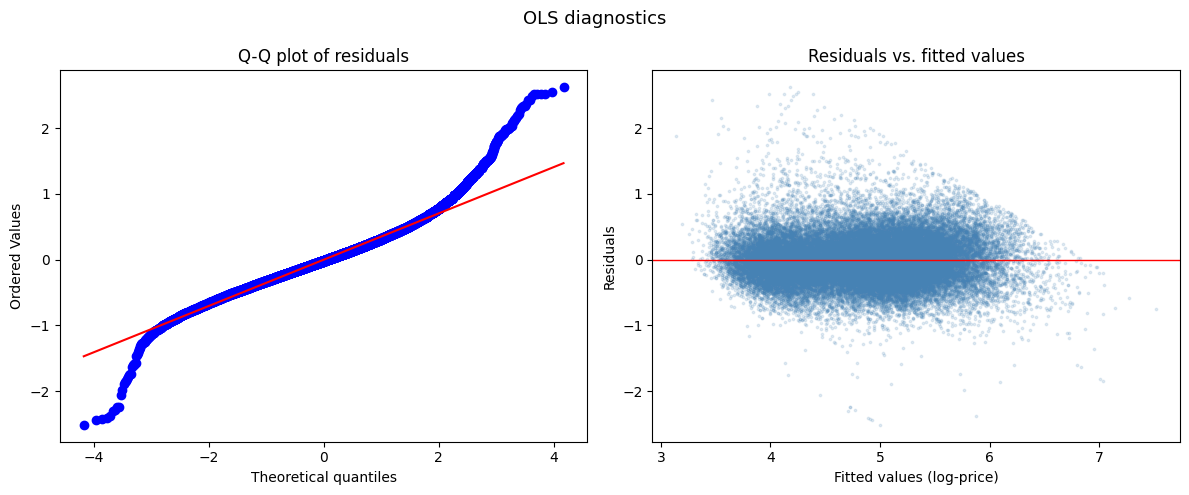

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Q-Q-Diagramm der OLS-Residuen
residuals_ols = ols.resid
stats.probplot(residuals_ols, dist='norm', plot=axes[0])
axes[0].set_title('Q-Q plot of residuals')
axes[0].get_lines()[1].set_color('red')

# Residuen vs. Angepasste Werte
fitted_ols = ols.fittedvalues
axes[1].scatter(fitted_ols, residuals_ols, alpha=0.15, s=3, color='steelblue')
axes[1].axhline(0, color='red', linewidth=1)
axes[1].set_xlabel('Fitted values (log-price)')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residuals vs. fitted values')

plt.suptitle('OLS diagnostics', fontsize=13)
plt.tight_layout()
plt.show()

### Interpreting the OLS diagnostics

**VIF (variance inflation factor):** Values > 10 signal problematic multicollinearity. The borough dummies are deliberately excluded - they are correlated by construction. Among the direct features, the largest centered VIF is about 3.3 (`accommodates`), far below the critical threshold: removing redundant features (e.g. `beds`) during preprocessing resolved the multicollinearity concern.

**Breusch-Pagan / HC3:** The Breusch-Pagan test rejects constant error variance decisively, as expected for price data. All reported conclusions are therefore checked against HC3-robust standard errors - no coefficient changes its significance status.

**Q-Q plot:** If the residual distribution lay exactly on the dashed line, it would be perfectly normal. Deviations in the tails (heavy tails) are typical for price data - outliers that the model systematically under- or overestimates. The log transformation mitigates but does not fully remove this effect.

**Residuals vs. fitted values:** An ideal horizontal cloud without pattern signals homoskedasticity. A funnel shape (larger spread at high fitted values) indicates heteroskedasticity - typical for price models and confirmed by the Breusch-Pagan test above, which is why HC3 standard errors are reported.


### 4.1 SHAP decomposition of the OLS prediction - feature influence

The estimated coefficients alone do not show **how strongly** a feature actually drives the prediction: a coefficient on a 0/1 flag is not comparable to a coefficient on `amenity_count` (range 1–100+), because the features have different scales and dispersions.

For a linear model, the contribution of a feature to an individual prediction can be stated exactly:

$$\phi_i = \beta_i \cdot (x_i - \overline{x_i})$$

The contribution is the coefficient weighted by the deviation of the feature value from the sample mean. This is exactly the SHAP decomposition for linear models - it puts all features on the same unit (effect on log(1+price)) and makes them directly comparable, analogous to the tree SHAP in Section 6. The **mean absolute SHAP value** per feature measures its global influence on the prediction.


Mean |SHAP| influence on log(1+price) - OLS (top 15)
Borough (all nb_* dummies)        0.2508
is_entire_home                    0.1935
distance_to_center_m              0.1777
accommodates                      0.1096
bedrooms                          0.0982
is_shared_bath                    0.0790
estimated_occupancy_l365d         0.0737
availability_365                  0.0492
bathrooms                         0.0478
host_is_superhost                 0.0472
review_scores_location            0.0257
calculated_host_listings_count    0.0253
amenity_count                     0.0216
is_professional_host              0.0197
has_balcony                       0.0182


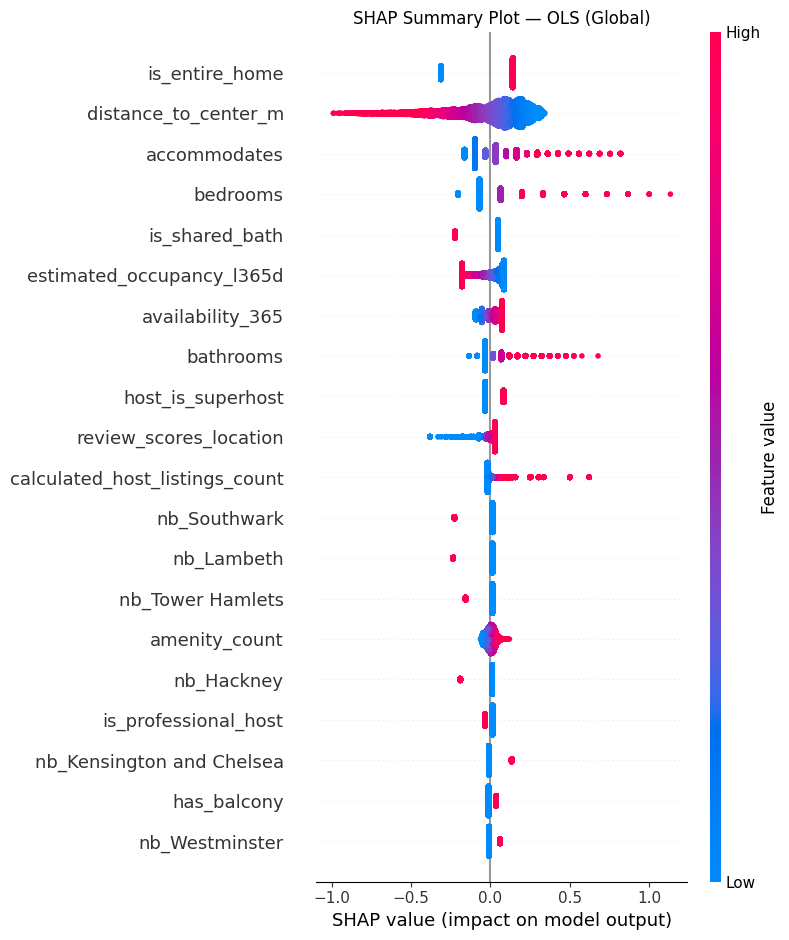

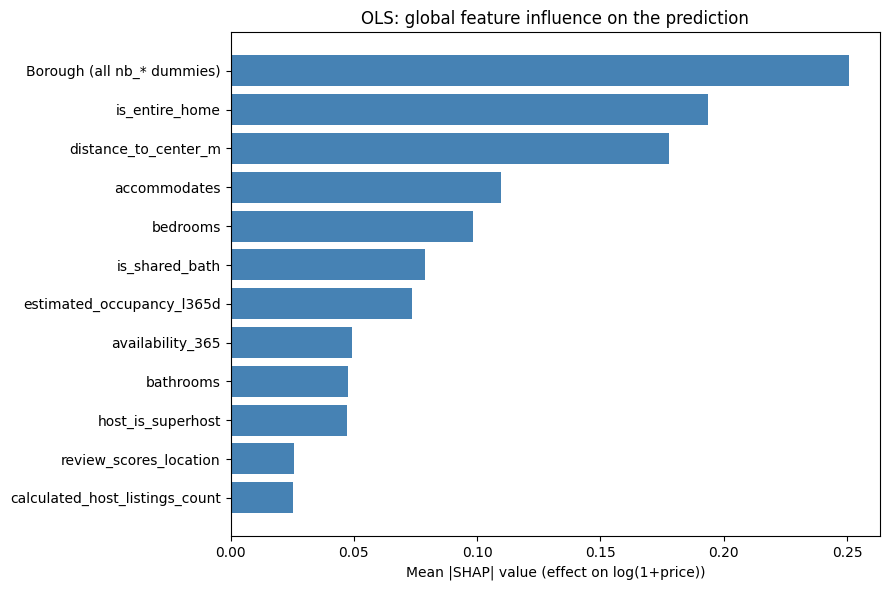

In [25]:
# SHAP decomposition of the OLS model (exact for linear models):
#   phi_i = beta_i * (x_i - mean(x_i))   -> contribution of each feature to the prediction
beta_ols = ols.params.drop('const')
X_lin    = X_ols.drop(columns='const')
shap_ols = (X_lin - X_lin.mean()) * beta_ols          # rows = listings, columns = features

# Global influence = mean absolute SHAP value per feature
imp_ols = shap_ols.abs().mean().sort_values(ascending=False)

# Aggregate the 33 borough dummies into one group (otherwise they dominate the list)
nb_mask = imp_ols.index.str.startswith('nb_')
imp_grouped = imp_ols[~nb_mask].copy()
imp_grouped['Borough (all nb_* dummies)'] = imp_ols[nb_mask].sum()
imp_grouped = imp_grouped.sort_values(ascending=False)

print('Mean |SHAP| influence on log(1+price) - OLS (top 15)')
print(imp_grouped.head(15).round(4).to_string())

# Beeswarm summary, same convention as the XGBoost plot in section 6 (top 20, boroughs individually)
with plt.rc_context(RC_PLOT):
    shap.summary_plot(shap_ols.values, X_lin, feature_names=list(X_lin.columns),
                      show=False, max_display=20)
    plt.title('SHAP Summary Plot — OLS (Global)', color='black')
    plt.tight_layout()
    plt.show()

# Bar chart of the global influence (features + aggregated boroughs)
with plt.rc_context(RC_PLOT):
    fig, ax = plt.subplots(figsize=(9, 6))
    top = imp_grouped.head(12)[::-1]
    ax.barh(top.index, top.values, color='steelblue')
    ax.set_xlabel('Mean |SHAP| value (effect on log(1+price))')
    ax.set_title('OLS: global feature influence on the prediction')
    plt.tight_layout()
    plt.show()

### 4.2 Decomposing the amenity effect

Amenities enter the model through five features: the total count `amenity_count` and four binary flags (`has_pool`, `has_hot_tub`, `has_bathtub`, `has_balcony`). Here their contribution is reported in isolation: the percentage price effect per feature (e^β − 1), statistical significance (p-value), and the pooled share of amenities in the total feature influence.

Note: `amenity_count` is an effect **per additional amenity**, the `has_*` flags an effect **for presence versus absence**.


Amenity features in the OLS model


,Feature,Coefficient b,Effect e^b,Price effect %,p-value,Mean |SHAP|,Presence
0,amenity_count,0.0019,1.0019,0.19,0.0000,0.0216,mean 33 items
1,has_pool,0.1087,1.1148,11.48,0.0000,0.0025,1.2%
2,has_hot_tub,0.0192,1.0194,1.94,0.1256,0.0007,1.9%
3,has_bathtub,0.0178,1.0179,1.79,0.0000,0.0088,45.9%
4,has_balcony,0.0483,1.0495,4.95,0.0000,0.0182,25.1%



All 5 amenity features together contribute 4.1% of the total mean |SHAP| influence.


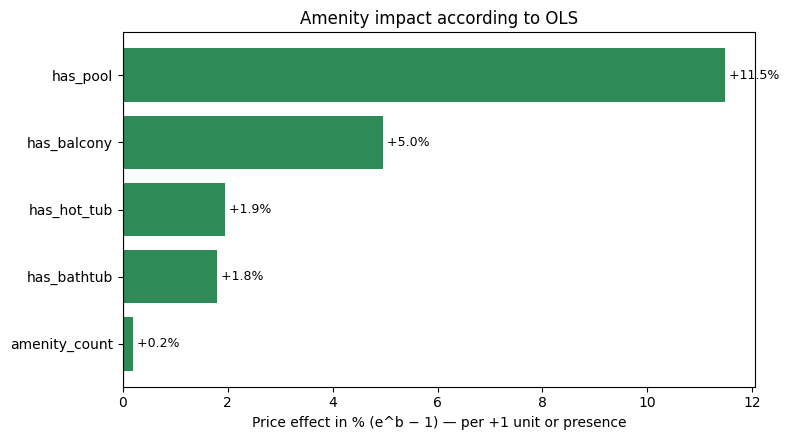

In [26]:
# Look at the amenity features in isolation
amenity_feats = [f for f in ['amenity_count', 'has_pool', 'has_hot_tub', 'has_bathtub', 'has_balcony']
                 if f in beta_ols.index]

rows = []
for f in amenity_feats:
    b = beta_ols[f]
    rows.append({
        'Feature':        f,
        'Coefficient b':  round(b, 4),
        'Effect e^b':     round(float(np.exp(b)), 4),
        'Price effect %': round(float(np.exp(b) - 1) * 100, 2),   # per +1 unit or presence
        'p-value':        round(float(ols.pvalues[f]), 4),
        'Mean |SHAP|':    round(float(shap_ols[f].abs().mean()), 4),
        'Presence':       (f'{df[f].mean()*100:.1f}%'if f.startswith('has_') else f'mean {df[f].mean():.0f} items'),
    })
amen_tbl = pd.DataFrame(rows)
print('Amenity features in the OLS model')
display(amen_tbl)

# Pooled share of amenities in the total mean |SHAP| influence
share = shap_ols[amenity_feats].abs().mean().sum() / shap_ols.abs().mean().sum() * 100
print(f'\nAll {len(amenity_feats)} amenity features together contribute {share:.1f}% '
      f'of the total mean |SHAP| influence.')

# Bar chart: percentage price effect of the individual amenities
with plt.rc_context(RC_PLOT):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    plot_df = amen_tbl.sort_values('Price effect %')
    colors = ['firebrick'if v < 0 else 'seagreen'for v in plot_df['Price effect %']]
    ax.barh(plot_df['Feature'], plot_df['Price effect %'], color=colors)
    ax.axvline(0, color='black', lw=0.8)
    ax.set_xlabel('Price effect in % (e^b − 1) — per +1 unit or presence')
    ax.set_title('Amenity impact according to OLS')
    for y, v in enumerate(plot_df['Price effect %']):
        ax.text(v, y, f' {v:+.1f}%', va='center',
                ha='left'if v >= 0 else 'right', color='black', fontsize=9)
    plt.tight_layout()
    plt.show()

## 5. Machine-learning analysis

Five models are compared for price prediction. Instead of a single train/test split,
**5-fold cross-validation** is used: the dataset is split into five equal parts;
each part serves once as the test set and four times as training data. Reported is the
mean ± std over the five folds - a more robust, less split-dependent performance estimate.

| Model | Type | Special feature |
|---|---|---|
| XGBoost | gradient boosting | sequential error correction, **early stopping** |
| Random Forest / Extra Trees | bagging | parallel trees, robust |
| Neural network (MLP) | NN | nonlinear, internal early stopping |
| Ridge regression | linear | regularised linear benchmark (subsumes OLS) |
| Mean predictor | baseline | predicts the training-fold mean - naive reference point |

**Methodology:**
- **Target variable** `log(1+price)`; back-transformation with the **Duan smearing estimator** (corrects the log bias), estimated per training fold.
- **Scaling** with `StandardScaler` (fitted on the training data of each fold only -> no data leakage).
- **Hyperparameters** per model determined once with **Optuna** on a fixed tuning split, then evaluated with k-fold CV.
- **Early stopping** for XGBoost: an internal validation set is split off per fold; the number of trees
  is chosen data-driven (instead of a fixed 1000) -> lower overfitting risk.
- **Linear & Ridge combined:** Since with n ≫ p (45,608 rows, 51 features) OLS and Ridge produce practically
  identical errors, Ridge serves as the single linear benchmark (the OLS inference was done in Section 4).


In [27]:
# Configuration of the ML evaluation
N_SPLITS        = 5    # k-fold cross-validation
N_TRIALS_BOOST  = 40   # Optuna trials for XGBoost
N_TRIALS_OTHER  = 25   # Optuna trials for Random Forest / Extra Trees / NN
RANDOM_STATE    = 42

X = df.drop(columns='price_dollar')
y = np.log1p(df['price_dollar'])
feature_names = list(X.columns)
print(f'ML dataset: {X.shape[0]:,} listings × {X.shape[1]} features')

# Fixed tuning split for Optuna - separate from the final k-fold evaluation
X_tune_tr_raw, X_tune_val_raw, y_tune_tr, y_tune_val = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE)
_sc_tune   = StandardScaler()
X_tune_tr  = _sc_tune.fit_transform(X_tune_tr_raw)
X_tune_val = _sc_tune.transform(X_tune_val_raw)
print(f'Tuning split (Optuna, fixed): {X_tune_tr_raw.shape[0]:,} train / {X_tune_val_raw.shape[0]:,} validation (80/20)')
print(f'Final evaluation: {N_SPLITS}-fold cross-validation -> per fold ~{X.shape[0]*(N_SPLITS-1)//N_SPLITS:,} train / ~{X.shape[0]//N_SPLITS:,} test (every listing 1x out-of-sample)')

def _metrics(model, X_fit_s, y_fit, X_te_s, y_te):
    """Back-transformation (Duan smearing) + 6 error metrics on the dollar scale."""
    res      = y_fit.values - model.predict(X_fit_s)
    smearing = np.mean(np.exp(res))
    y_pred   = np.exp(model.predict(X_te_s)) * smearing - 1
    y_true   = np.expm1(y_te)
    return dict(
        RMSE  = root_mean_squared_error(y_true, y_pred),
        MAE   = mean_absolute_error(y_true, y_pred),
        MedAE = median_absolute_error(y_true, y_pred),
        MAPE  = float(np.mean(np.abs((y_true - y_pred) / y_true)) * 100),
        R2    = r2_score(y_true, y_pred),
        Acc20 = float(np.mean(np.abs((y_true - y_pred) / y_true) <= 0.20) * 100),
    )

def cv_evaluate(model_factory, fit_mode='plain', n_splits=N_SPLITS):
    """K-fold CV. fit_mode 'xgb'uses early stopping on an internal validation set."""
    kf   = KFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    keys = ['RMSE','MAE','MedAE','MAPE','R2','Acc20']
    acc  = {k: [] for k in keys}
    for tr, te in kf.split(X):
        Xtr, Xte = X.iloc[tr], X.iloc[te]
        ytr, yte = y.iloc[tr], y.iloc[te]
        sc = StandardScaler()
        Xtr_s, Xte_s = sc.fit_transform(Xtr), sc.transform(Xte)
        m = model_factory()
        if fit_mode == 'xgb':
            Xa, Xv, ya, yv = train_test_split(Xtr_s, ytr, test_size=0.2, random_state=RANDOM_STATE)
            m.fit(Xa, ya, eval_set=[(Xv, yv)], verbose=False)
            md_ = _metrics(m, Xa, ya, Xte_s, yte)
        else:
            m.fit(Xtr_s, ytr)
            md_ = _metrics(m, Xtr_s, ytr, Xte_s, yte)
        for k in keys: acc[k].append(md_[k])
    return {k: np.array(v) for k, v in acc.items()}

def report(name, res):
    print(f"{name:<20} RMSE ${res['RMSE'].mean():6.2f}±{res['RMSE'].std():4.2f}  "
          f"MAE ${res['MAE'].mean():6.2f}  MedAE ${res['MedAE'].mean():6.2f}  "
          f"MAPE {res['MAPE'].mean():4.1f}%  R² {res['R2'].mean():.3f}  ±20% {res['Acc20'].mean():4.1f}%")

results = {}

ML dataset: 45,608 listings × 51 features
Tuning split (Optuna, fixed): 36,486 train / 9,122 validation (80/20)
Final evaluation: 5-fold cross-validation -> per fold ~36,486 train / ~9,121 test (every listing 1x out-of-sample)


### 5.1 XGBoost (gradient boosting, early stopping)


In [28]:
def obj_xgb(trial):
    params = dict(
        n_estimators=1000, early_stopping_rounds=50, eval_metric='rmse', verbosity=0,
        learning_rate    = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        max_depth        = trial.suggest_int('max_depth', 3, 10),
        subsample        = trial.suggest_float('subsample', 0.5, 1.0),
        colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0),
        min_child_weight = trial.suggest_int('min_child_weight', 1, 10),
        reg_alpha        = trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        reg_lambda       = trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True),
        random_state=RANDOM_STATE)
    m = xgb.XGBRegressor(**params)
    m.fit(X_tune_tr, y_tune_tr, eval_set=[(X_tune_val, y_tune_val)], verbose=False)
    return root_mean_squared_error(y_tune_val, m.predict(X_tune_val))

study_xgb = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_xgb.optimize(obj_xgb, n_trials=N_TRIALS_BOOST)
best_xgb = study_xgb.best_params
print('Best XGBoost parameters:', best_xgb)

def make_xgb():
    return xgb.XGBRegressor(**best_xgb, n_estimators=1000, early_stopping_rounds=50,
                            eval_metric='rmse', verbosity=0, random_state=RANDOM_STATE)
results['XGBoost'] = cv_evaluate(make_xgb, fit_mode='xgb')
report('XGBoost', results['XGBoost'])

Best XGBoost parameters: {'learning_rate': 0.02358616435216281, 'max_depth': 10, 'subsample': 0.9073046991591618, 'colsample_bytree': 0.6807632133703729, 'min_child_weight': 7, 'reg_alpha': 6.4599471023250054e-06, 'reg_lambda': 0.001359772405064471}


XGBoost              RMSE $ 68.53±1.86  MAE $ 38.10  MedAE $ 20.46  MAPE 23.0%  R² 0.726  ±20% 56.0%


### 5.2 Random Forest (bagging)


In [29]:
def obj_rf(trial):
    m = RandomForestRegressor(
        n_estimators     = trial.suggest_int('n_estimators', 200, 600),
        max_depth        = trial.suggest_int('max_depth', 5, 30),
        min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10),
        max_features     = trial.suggest_float('max_features', 0.3, 1.0),
        random_state=RANDOM_STATE, n_jobs=-1)
    m.fit(X_tune_tr, y_tune_tr)
    return root_mean_squared_error(y_tune_val, m.predict(X_tune_val))

study_rf = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_rf.optimize(obj_rf, n_trials=N_TRIALS_OTHER)
best_rf = study_rf.best_params
print('Best Random Forest parameters:', best_rf)

def make_rf():
    return RandomForestRegressor(**best_rf, random_state=RANDOM_STATE, n_jobs=-1)
results['Random Forest'] = cv_evaluate(make_rf, fit_mode='plain')
report('Random Forest', results['Random Forest'])

Best Random Forest parameters: {'n_estimators': 390, 'max_depth': 24, 'min_samples_leaf': 2, 'max_features': 0.30320441832906425}


Random Forest        RMSE $ 72.05±1.84  MAE $ 39.87  MedAE $ 21.51  MAPE 24.2%  R² 0.697  ±20% 53.7%


### 5.3 Extra Trees (extremely randomized trees)


In [30]:
def obj_et(trial):
    m = ExtraTreesRegressor(
        n_estimators     = trial.suggest_int('n_estimators', 200, 600),
        max_depth        = trial.suggest_int('max_depth', 5, 30),
        min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10),
        max_features     = trial.suggest_float('max_features', 0.3, 1.0),
        random_state=RANDOM_STATE, n_jobs=-1)
    m.fit(X_tune_tr, y_tune_tr)
    return root_mean_squared_error(y_tune_val, m.predict(X_tune_val))

study_et = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_et.optimize(obj_et, n_trials=N_TRIALS_OTHER)
best_et = study_et.best_params
print('Best Extra Trees parameters:', best_et)

def make_et():
    return ExtraTreesRegressor(**best_et, random_state=RANDOM_STATE, n_jobs=-1)
results['Extra Trees'] = cv_evaluate(make_et, fit_mode='plain')
report('Extra Trees', results['Extra Trees'])

Best Extra Trees parameters: {'n_estimators': 382, 'max_depth': 25, 'min_samples_leaf': 2, 'max_features': 0.6599641068895281}


Extra Trees          RMSE $ 71.39±1.88  MAE $ 39.27  MedAE $ 20.87  MAPE 23.7%  R² 0.703  ±20% 54.8%


### 5.4 Neural network (MLP)


In [31]:
ARCH = {
    '64': (64,), '128': (128,), '256': (256,),
    '256-128': (256, 128), '128-64': (128, 64),
    '256-128-64': (256, 128, 64), '512-256-128': (512, 256, 128), '128-64-32': (128, 64, 32),
}

def obj_nn(trial):
    m = MLPRegressor(
        hidden_layer_sizes = ARCH[trial.suggest_categorical('arch', list(ARCH))],
        activation         = trial.suggest_categorical('activation', ['relu', 'tanh']),
        learning_rate_init = trial.suggest_float('learning_rate_init', 1e-4, 1e-1, log=True),
        alpha              = trial.suggest_float('alpha', 1e-5, 1e-1, log=True),
        max_iter=500, early_stopping=True, validation_fraction=0.1, random_state=RANDOM_STATE)
    m.fit(X_tune_tr, y_tune_tr)
    return root_mean_squared_error(np.expm1(y_tune_val), np.expm1(m.predict(X_tune_val)))

study_nn = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_nn.optimize(obj_nn, n_trials=N_TRIALS_OTHER)
best_nn = study_nn.best_params
print('Best NN parameters:', best_nn)

def make_nn():
    return MLPRegressor(
        hidden_layer_sizes=ARCH[best_nn['arch']], activation=best_nn['activation'],
        learning_rate_init=best_nn['learning_rate_init'], alpha=best_nn['alpha'],
        max_iter=500, early_stopping=True, validation_fraction=0.1, random_state=RANDOM_STATE)
results['Neural Network'] = cv_evaluate(make_nn, fit_mode='plain')
report('Neural Network', results['Neural Network'])

Best NN parameters: {'arch': '128-64-32', 'activation': 'tanh', 'learning_rate_init': 0.0004709615803497645, 'alpha': 0.0006305038064019104}


Neural Network       RMSE $ 73.92±1.79  MAE $ 43.33  MedAE $ 24.71  MAPE 27.6%  R² 0.681  ±20% 48.7%


### 5.5 Ridge regression (linear benchmark)

Regularised linear regression; α chosen automatically via 5-fold CV. Serves as the combined linear/OLS benchmark (cf. Section 4).


In [32]:
def make_ridge():
    return RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0, 100.0, 1000.0], cv=5)
results['Ridge'] = cv_evaluate(make_ridge, fit_mode='plain')
report('Ridge', results['Ridge'])

Ridge                RMSE $ 81.76±2.12  MAE $ 47.54  MedAE $ 27.41  MAPE 31.0%  R² 0.610  ±20% 44.3%


### 5.6 Model comparison


Mean baseline        RMSE $130.96±1.72  MAE $ 92.08  MedAE $ 75.76  MAPE 89.9%  R² -0.000  ±20% 21.7%

Model                     RMSE ($)   MAE ($)  MedAE ($)  MAPE (%)      R²  ±20% (%)

XGBoost                68.53 ±1.86     38.10      20.46      23.0   0.726      56.0
Extra Trees            71.39 ±1.88     39.27      20.87      23.7   0.703      54.8
Random Forest          72.05 ±1.84     39.87      21.51      24.2   0.697      53.7
Neural Network         73.92 ±1.79     43.33      24.71      27.6   0.681      48.7
Ridge                  81.76 ±2.12     47.54      27.41      31.0   0.610      44.3
Mean baseline         130.96 ±1.72     92.08      75.76      89.9  -0.000      21.7

Paired fold difference (Extra Trees − XGBoost): mean $2.87 ± 0.40  |  XGBoost has the lower RMSE in 5/5 folds


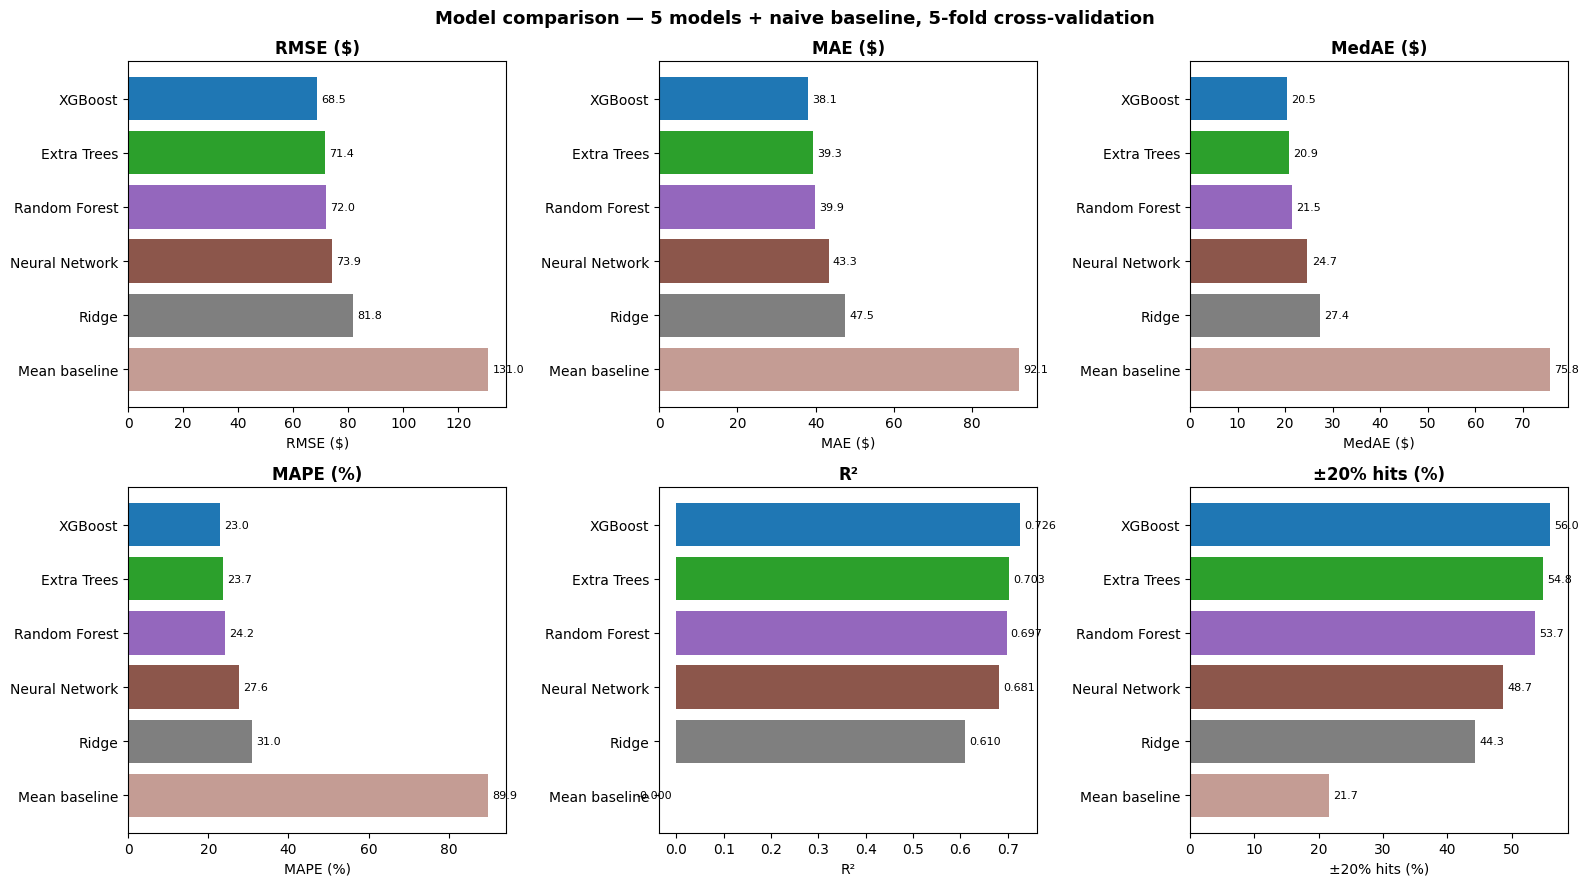

In [33]:
# Naive baseline: predict the training-fold mean (identical protocol incl. Duan)
class MeanRegressor:
    """Predicts the mean of the (log) training target - anchors what the models add."""
    def fit(self, X, y):
        self.mu_ = float(np.mean(y))
        return self
    def predict(self, X):
        return np.full(len(X), self.mu_)

results['Mean baseline'] = cv_evaluate(MeanRegressor, fit_mode='plain')
report('Mean baseline', results['Mean baseline'])

# Comparison table (mean over 5 folds; RMSE with fold-level std)
order = sorted(results, key=lambda n: results[n]['RMSE'].mean())
print(f"\n{'Model':<20}{'RMSE ($)':>14}{'MAE ($)':>10}{'MedAE ($)':>11}"
      f"{'MAPE (%)':>10}{'R²':>8}{'±20% (%)':>10}")
print('' * 83)
for n in order:
    m = results[n]
    print(f"{n:<20}{m['RMSE'].mean():>8.2f} ±{m['RMSE'].std():4.2f}{m['MAE'].mean():>10.2f}{m['MedAE'].mean():>11.2f}"
          f"{m['MAPE'].mean():>10.1f}{m['R2'].mean():>8.3f}{m['Acc20'].mean():>10.1f}")

# Paired fold-level comparison of the two best models
# CV folds share training data, so formal significance tests are anticonservative
# (Nadeau & Bengio 2003); reported instead: paired per-fold differences.
d = results['Extra Trees']['RMSE'] - results['XGBoost']['RMSE']
print(f"\nPaired fold difference (Extra Trees − XGBoost): mean ${d.mean():.2f} ± {d.std():.2f}"
      f"  |  XGBoost has the lower RMSE in {(d > 0).sum()}/{len(d)} folds")

# Bar charts: fixed colour PER MODEL across all metrics
MODEL_COLOR = {
    'XGBoost':'#1f77b4', 'Extra Trees':'#2ca02c',
    'Random Forest':'#9467bd', 'Neural Network':'#8c564b', 'Ridge':'#7f7f7f',
    'Mean baseline':'#c49c94',
}
fixed_order = sorted(results, key=lambda n: results[n]['RMSE'].mean())   # same order in every subplot
metrics_plot = [('RMSE','RMSE ($)','%.1f'), ('MAE','MAE ($)','%.1f'), ('MedAE','MedAE ($)','%.1f'),
                ('MAPE','MAPE (%)','%.1f'), ('R2','R²','%.3f'), ('Acc20','±20% hits (%)','%.1f')]
with plt.rc_context(RC_PLOT):
    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    yrev = list(reversed(fixed_order))    # best model on top
    for ax, (key, label, fmt) in zip(axes.flat, metrics_plot):
        vals = [results[n][key].mean() for n in yrev]
        cols = [MODEL_COLOR.get(n, '#333333') for n in yrev]
        bars = ax.barh(yrev, vals, color=cols)
        ax.set_xlabel(label); ax.set_title(label, fontweight='bold')
        ax.bar_label(bars, fmt=fmt, padding=3, fontsize=8)
    plt.suptitle('Model comparison — 5 models + naive baseline, 5-fold cross-validation',
                 fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

#### Interpretation

The **boosting model XGBoost** achieves the lowest RMSE, as expected, because it captures
nonlinear relationships and feature interactions automatically. **Random Forest** and **Extra Trees**
follow closely, the **neural network** sits in the middle. **Ridge regression** marks the linear
benchmark - the gap to the tree models quantifies the nonlinearity share in the market. The
**mean-predictor baseline** anchors the scale: every model at least halves its error.

The small standard deviations over the five folds document a **stable model ranking**; XGBoost has
the lowest RMSE in every single fold. `MedAE` lies well below `MAE`/`RMSE`: most predictions are
close to the true price, while a few expensive listings inflate the mean errors.


## 6. Explainable AI (XAI)

The best boosting model is interpreted with **SHAP** (global & local attributions), **PDP**, and **ICE**.
For the XAI analysis, a final XGBoost and a Random Forest model are trained on an 80/20 holdout with the
parameters determined in Section 5 (the performance evaluation there used cross-validation).


In [34]:
# Final XAI models (XGBoost with early stopping + Random Forest) on an 80/20 holdout
X_tr_f, X_te_f, y_tr_f, y_te_f = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
_sc_f       = StandardScaler()
X_train_xgb = _sc_f.fit_transform(X_tr_f)
X_test_xgb  = _sc_f.transform(X_te_f)

_Xa, _Xv, _ya, _yv = train_test_split(X_train_xgb, y_tr_f, test_size=0.2, random_state=RANDOM_STATE)
final_xgb = xgb.XGBRegressor(**best_xgb, n_estimators=1000, early_stopping_rounds=50,
                             eval_metric='rmse', verbosity=0, random_state=RANDOM_STATE)
final_xgb.fit(_Xa, _ya, eval_set=[(_Xv, _yv)], verbose=False)

final_rf = RandomForestRegressor(**best_rf, random_state=RANDOM_STATE, n_jobs=-1)
final_rf.fit(X_train_xgb, y_tr_f)
print('Final XAI models trained (XGBoost + Random Forest).')

Final XAI models trained (XGBoost + Random Forest).


In [35]:
# Compute SHAP values for XGBoost (once; reused in all SHAP plots)
X_shap_df = pd.DataFrame(X_test_xgb, columns=X.columns)
n_shap    = min(2000, len(X_shap_df))
rng       = np.random.default_rng(42)
idx_shap  = rng.integers(0, len(X_shap_df), size=n_shap)
X_shap_samp = X_shap_df.iloc[idx_shap]

explainer   = shap.TreeExplainer(final_xgb)
shap_values = explainer.shap_values(X_shap_samp)
print(f'SHAP values computed: {X_shap_samp.shape[0]} listings × {X_shap_samp.shape[1]} features')

SHAP values computed: 2000 listings × 51 features


### 6.1 SHAP global - summary plot

Each dot is one listing. The y-axis shows the features sorted by global influence (top = most important feature). The x-axis shows the SHAP value: positive values push the price up, negative values push it down. The colour encodes the feature value (red = high, blue = low).


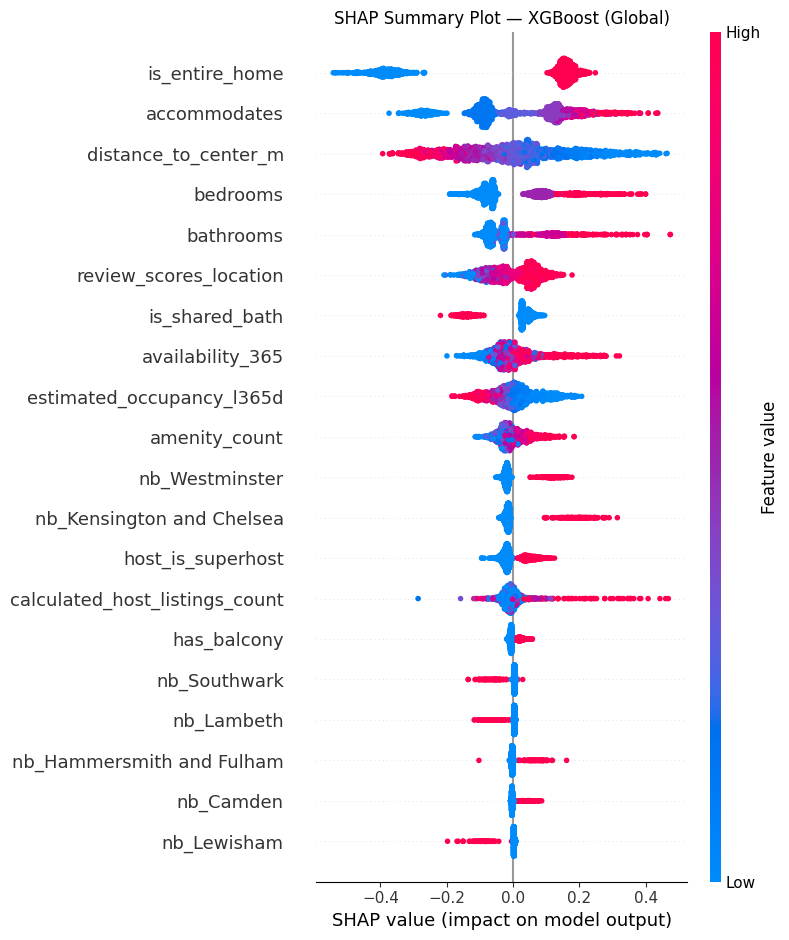

In [36]:
with plt.rc_context(RC_PLOT):
    shap.summary_plot(shap_values, X_shap_samp, feature_names=list(X.columns), show=False)
    plt.title('SHAP Summary Plot — XGBoost (Global)', color='black')
    plt.tight_layout()
    plt.show()

### 6.2 SHAP local - waterfall plots for individual listings

The waterfall plot shows how each feature moves the price of **a single listing** from the baseline (expected price without additional information) to the actual prediction.

- **Red bars** -> feature pushes the price up
- **Blue bars** -> feature pushes the price down
- **E[f(x)]** -> mean prediction (baseline)
- **f(x)** -> actual prediction for this listing


Cheapest listing in the sample       : $28/night
Most expensive listing in the sample : $893/night


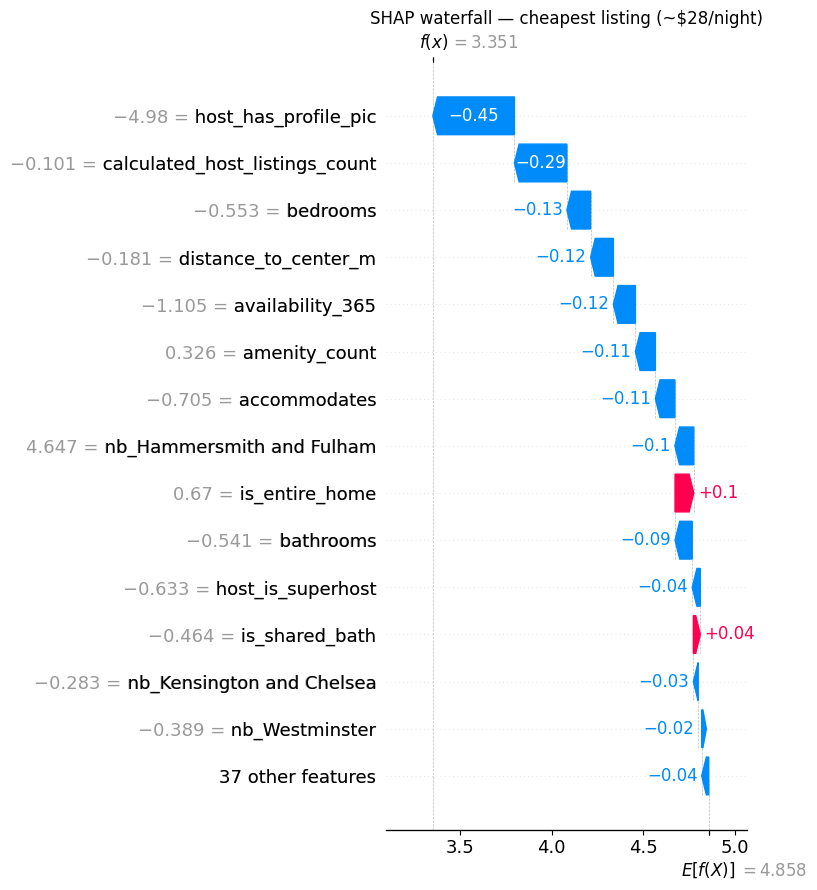

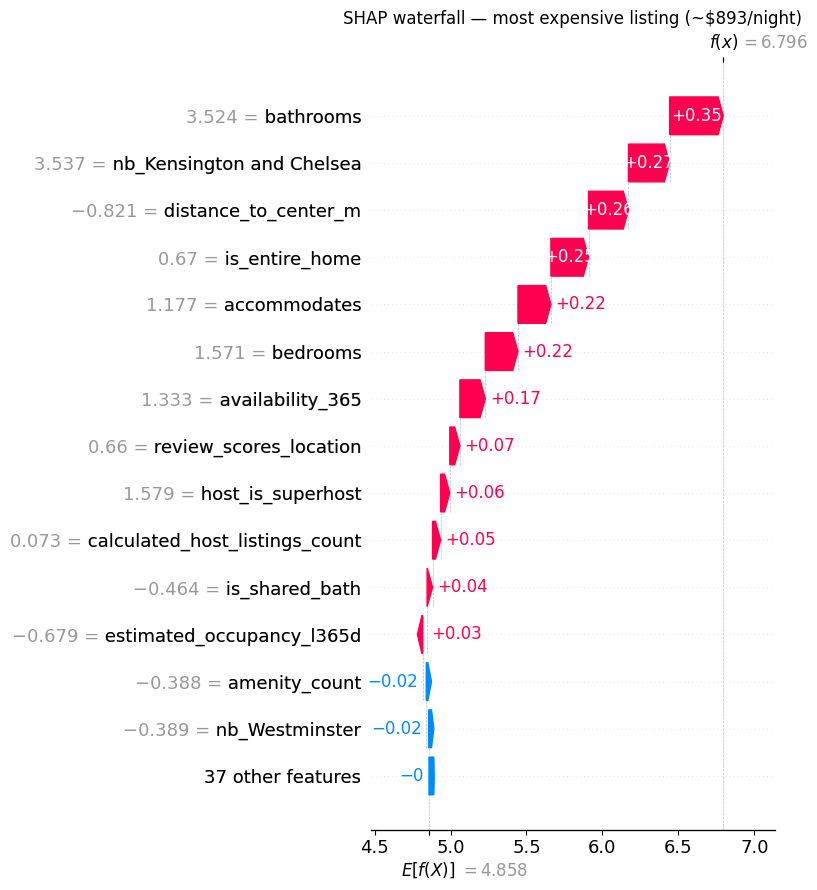

In [37]:
# SHAP explanation object (required for waterfall plots)
shap_expl = explainer(X_shap_samp)

# Find the most expensive and the cheapest listing in the sample
y_pred_shap = final_xgb.predict(X_shap_samp.values)
idx_cheap   = int(np.argmin(y_pred_shap))   # cheap listing
idx_exp     = int(np.argmax(y_pred_shap))   # expensive listing

pred_cheap = np.expm1(y_pred_shap[idx_cheap])
pred_exp   = np.expm1(y_pred_shap[idx_exp])
print(f'Cheapest listing in the sample       : ${pred_cheap:.0f}/night')
print(f'Most expensive listing in the sample : ${pred_exp:.0f}/night')

# Note: shap.waterfall_plot creates its own figure and ignores pre-defined subplot axes.
# The two listings are therefore drawn in separate figures (otherwise the plots overlap).
with plt.rc_context(RC_PLOT):
    shap.waterfall_plot(shap_expl[idx_cheap], max_display=15, show=False)
    plt.title(f'SHAP waterfall — cheapest listing (~${pred_cheap:.0f}/night)',
              color='black', fontsize=12)
    plt.tight_layout()
    plt.show()

    shap.waterfall_plot(shap_expl[idx_exp], max_display=15, show=False)
    plt.title(f'SHAP waterfall — most expensive listing (~${pred_exp:.0f}/night)',
              color='black', fontsize=12)
    plt.tight_layout()
    plt.show()

### 6.3 SHAP local - force plots

The force plot is a more compact alternative to the waterfall plot. The base value (E[f(x)]) is pushed to the right (red = price-raising) or left (blue = price-lowering) by the features. The final prediction is on the right.


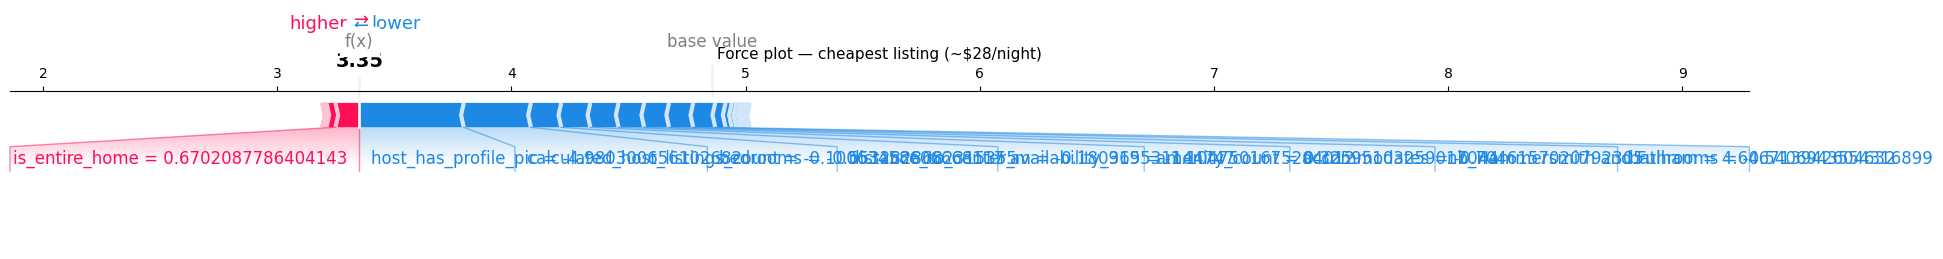

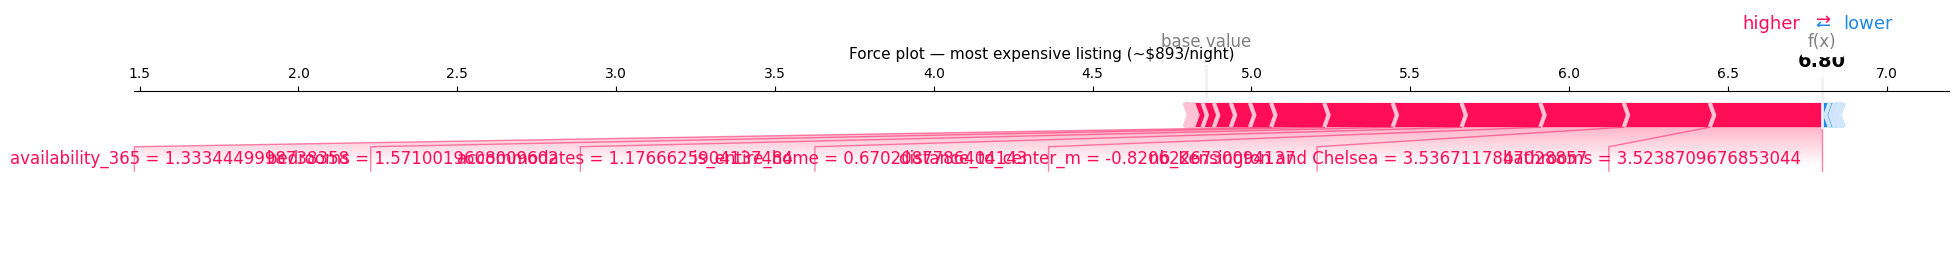

In [38]:
# Force plots as static matplotlib figures (reliable in exports, unlike the JS variant)
with plt.rc_context(RC_PLOT):
    shap.force_plot(explainer.expected_value, shap_values[idx_cheap], X_shap_samp.iloc[idx_cheap],
                    feature_names=feature_names, matplotlib=True, show=False)
    plt.title(f'Force plot — cheapest listing (~${pred_cheap:.0f}/night)', fontsize=11)
    plt.tight_layout(); plt.show()

    shap.force_plot(explainer.expected_value, shap_values[idx_exp], X_shap_samp.iloc[idx_exp],
                    feature_names=feature_names, matplotlib=True, show=False)
    plt.title(f'Force plot — most expensive listing (~${pred_exp:.0f}/night)', fontsize=11)
    plt.tight_layout(); plt.show()

### 6.4 PDP - partial dependence plots

PDPs show the **average marginal effect** of a feature on the prediction while all other features are averaged over their distribution (cf. Friedman 2001).

**Mathematically:** $\hat{f}_S(x_S) = \mathbb{E}_{x_C}[f(x_S, x_C)]$

Unlike OLS coefficients, PDPs can reveal nonlinear relationships and saturation effects. The curve is monotonic when the feature has a consistent effect, or takes a hump shape when the effect interacts with other features.


Top features for PDP/ICE: ['is_entire_home', 'accommodates', 'distance_to_center_m', 'bedrooms', 'bathrooms', 'review_scores_location']


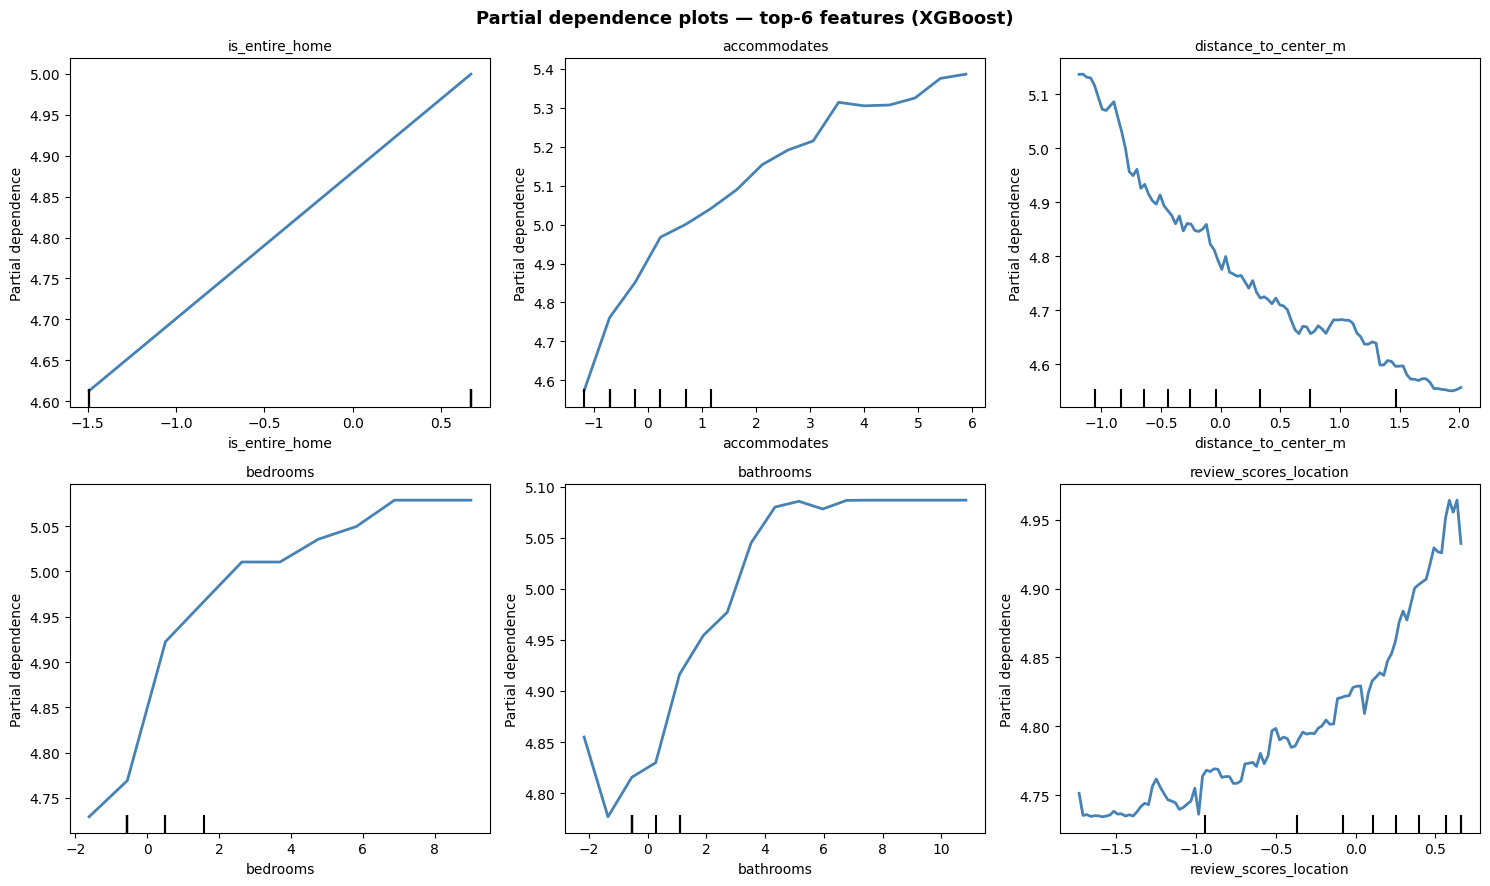

In [39]:
# Top-5 features by mean |SHAP| value (excluding nb_* dummies for readability)
mean_abs_shap   = np.abs(shap_values).mean(axis=0)
feature_names   = list(X.columns)
shap_importance = pd.Series(mean_abs_shap, index=feature_names)

top_features_pdp = (
    shap_importance[~shap_importance.index.str.startswith('nb_')]
    .nlargest(6)
    .index.tolist()
)
print('Top features for PDP/ICE:', top_features_pdp)

# Column indices
feat_idx = [feature_names.index(f) for f in top_features_pdp]

# PDP on the training set (scaled)
X_train_df = pd.DataFrame(X_train_xgb, columns=feature_names)

with plt.rc_context(RC_PLOT):
    fig, axes = plt.subplots(2, 3, figsize=(15, 9))
    for ax, feat, fi in zip(axes.flat, top_features_pdp, feat_idx):
        PartialDependenceDisplay.from_estimator(
            final_xgb, X_train_df, [fi],
            feature_names=feature_names,
            kind='average',
            ax=ax,
            line_kw={'color': 'steelblue', 'linewidth': 2},
        )
        ax.set_title(feat, color='black', fontsize=10)
        ax.tick_params(colors='black')
        ax.xaxis.label.set_color('black')
        ax.yaxis.label.set_color('black')
        ax.set_ylabel('Partial effect (log-price)', color='black')

    plt.suptitle('Partial dependence plots — top-6 features (XGBoost)',
                 color='black', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

### 6.5 ICE plots - individual conditional expectation

ICE plots (Goldstein et al. 2014) are the local extension of PDPs. Instead of the average, a separate curve is drawn for each listing. This reveals:

- **Heterogeneity**: do all listings react the same way to the feature, or are there subgroups?
- **Interactions**: crossing lines indicate that the feature interacts with other characteristics.
- The **thick orange line** is the PDP average.

For readability, only the **most important numeric features** are shown, each with a random sample of 300 listings.


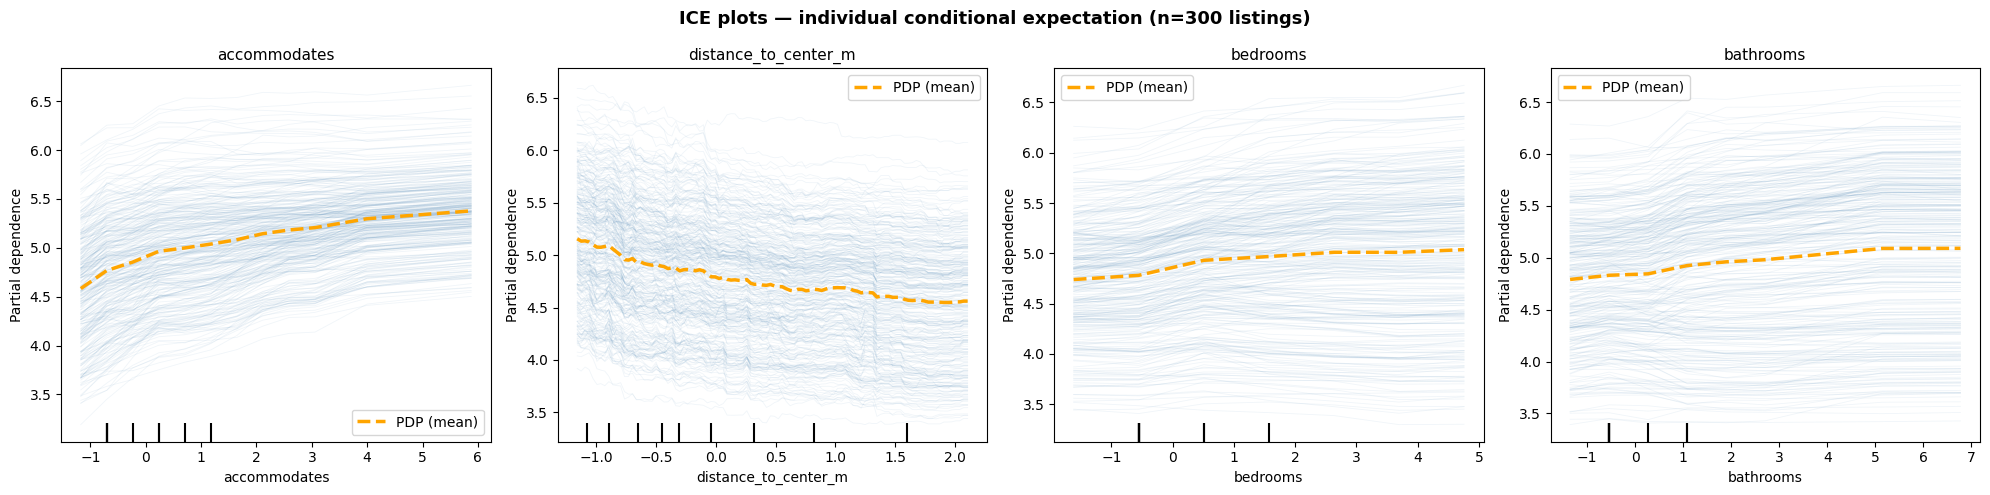

In [40]:
# Only numeric (non-binary) top features for ICE
num_top = [f for f in top_features_pdp if X[f].nunique() > 10][:4]
num_idx = [feature_names.index(f) for f in num_top]

# Sample for ICE (performance)
rng_ice    = np.random.default_rng(42)
ice_sample = rng_ice.choice(len(X_train_df), size=min(300, len(X_train_df)), replace=False)
X_ice_df   = X_train_df.iloc[ice_sample]

with plt.rc_context(RC_PLOT):
    fig, axes = plt.subplots(1, len(num_top), figsize=(5 * len(num_top), 5))
    if len(num_top) == 1:
        axes = [axes]

    for ax, feat, fi in zip(axes, num_top, num_idx):
        PartialDependenceDisplay.from_estimator(
            final_xgb, X_ice_df, [fi],
            feature_names=feature_names,
            kind='both',
            ax=ax,
            ice_lines_kw={'color': 'steelblue', 'alpha': 0.08, 'linewidth': 0.6},
            pd_line_kw={'color': 'orange', 'linewidth': 2.5, 'label': 'PDP (mean)'},
        )
        ax.set_title(feat, color='black', fontsize=11)
        ax.tick_params(colors='black')
        ax.xaxis.label.set_color('black')
        ax.yaxis.label.set_color('black')
        ax.set_ylabel('Partial effect (log-price)', color='black')
        ax.legend(facecolor='white', labelcolor='black', fontsize=8)

    plt.suptitle('ICE plots — individual conditional expectation (n=300 listings)',
                 color='black', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

#### How to read ICE plots

| Element | Meaning |
|---|---|
| **Individual blue lines** | One line per listing - shows how *this* listing reacts to changes in the feature |
| **Orange line** | PDP average - corresponds to the global marginal effect |
| **Parallel lines** | No interaction effect - all listings react the same way |
| **Crossing lines** | Interaction effect - listings react differently (e.g. expensive vs. cheap) |


### 6.6 SHAP comparison: XGBoost vs. Random Forest

Since Random Forest is also a tree model, `shap.TreeExplainer` can be applied directly. The comparison shows whether both models identify similar feature importances.


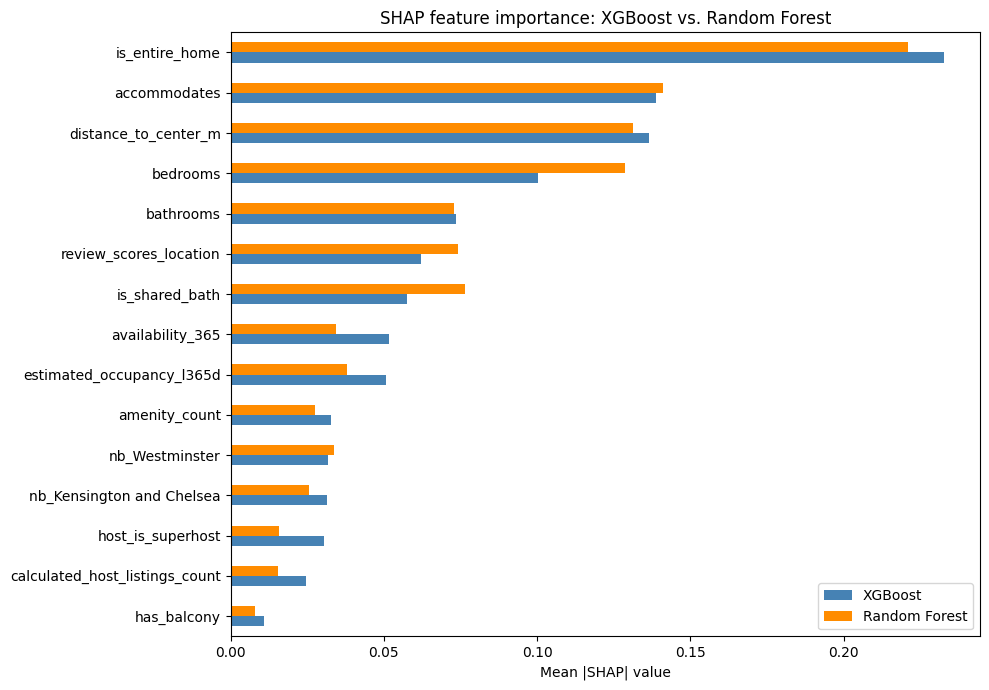

In [41]:
# Random Forest SHAP - on the same test set as XGBoost
explainer_rf    = shap.TreeExplainer(final_rf)
shap_values_rf  = explainer_rf.shap_values(X_shap_samp)

mean_shap_xgb = pd.Series(np.abs(shap_values).mean(axis=0),    index=feature_names)
mean_shap_rf  = pd.Series(np.abs(shap_values_rf).mean(axis=0), index=feature_names)

# Top-15 by XGBoost ranking
top15 = mean_shap_xgb.nlargest(15).index

comparison = pd.DataFrame({
    'XGBoost':       mean_shap_xgb[top15],
    'Random Forest': mean_shap_rf[top15],
}).sort_values('XGBoost')

with plt.rc_context(RC_PLOT):
    ax = comparison.plot(kind='barh', figsize=(10, 7), color=['steelblue', 'darkorange'])
    ax.set_xlabel('Mean |SHAP| value', color='black')
    ax.set_title('SHAP feature importance: XGBoost vs. Random Forest', color='black', fontsize=12)
    ax.tick_params(colors='black')
    ax.xaxis.label.set_color('black')
    ax.yaxis.label.set_color('black')
    legend = ax.legend(facecolor='white', labelcolor='black')
    plt.tight_layout()
    plt.show()

## 7. Critical evaluation


### Effect of the feature engineering

The following comparison contrasts the current XGBoost model with a baseline value from *before* the feature improvements (which still included the quasi-constant `has_wifi`/`has_kitchen`, the redundant `beds`, `review_scores_rating` instead of `review_scores_location`, and no `calculated_host_listings_count`).

**Caveat - not a strictly controlled comparison:** The baseline value ($74.92) was obtained under a *different* evaluation scheme - a single 80/20 split over several random seeds - while the "after" value is the mean of the **5-fold cross-validation**. The two numbers are therefore **not strictly comparable**: the comparison illustrates the *direction* and rough magnitude of the gain from feature engineering, but is not a clean A/B experiment. A fully controlled test would re-evaluate the old feature set under the same 5-fold CV protocol.


XGBoost RMSE  before: $74.92   after: $68.53   Δ -6.39


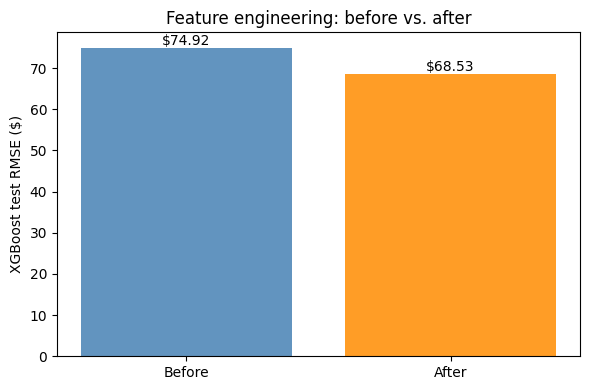

In [42]:
# Effect of the feature engineering: XGBoost RMSE before vs. after
# Baseline BEFORE the feature improvements (contained has_wifi/has_kitchen quasi-constant,
# beds redundant, review_scores_rating instead of _location, no calculated_host_listings_count).
# Note: the baseline stems from a different validation scheme (single split) than the CV above  - 
# see the caveat in the markdown cell above. The comparison is illustrative, not an A/B test.
baseline_xgb_rmse = 74.92
after_xgb_rmse    = results['XGBoost']['RMSE'].mean()
print(f"XGBoost RMSE  before: ${baseline_xgb_rmse:.2f}   after: ${after_xgb_rmse:.2f}   "
      f"Δ {after_xgb_rmse - baseline_xgb_rmse:+.2f}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['Before', 'After'], [baseline_xgb_rmse, after_xgb_rmse],
       color=['steelblue', 'darkorange'], alpha=0.85)
ax.set_ylabel('XGBoost test RMSE ($)')
ax.set_title('Feature engineering: before vs. after')
ax.bar_label(ax.containers[0], fmt='$%.2f')
plt.tight_layout(); plt.show()

### 7.1 Robustness of methods and parameter choices

**Cross-validation stability:** All five models were evaluated with 5-fold cross-validation; every data point enters the test set exactly once. The small standard deviations of the RMSE values document a consistent model ranking and speak for robust, non-overfitted estimates. Because CV folds share training data, formal significance tests on fold results are anticonservative (Nadeau & Bengio 2003); the paired per-fold differences reported in Section 5.6 are the appropriate summary.

**Optuna hyperparameter search:** XGBoost and the neural network were optimised with Optuna (40 trials for boosting, 25 for the others). A larger search budget might improve the results but is computationally more expensive. The early-stopping condition (50 rounds without improvement) prevents overfitting in XGBoost; the MLP uses a 10% validation share.

**Duan smearing correction:** Since the target variable is log-transformed, the naive back-transformation `expm1(ŷ)` systematically underestimates the true conditional mean (Jensen's inequality). The Duan smearing estimator corrects this bias: the correction factor is the mean exponential of the training residuals, estimated per training fold. For well-fitted models it is close to 1, but it has a measurable effect for weaker fits (e.g. neural network, Ridge).

**Ridge as the linear benchmark:** The nearly identical RMSE to plain OLS is statistically expected: with n ≫ p (45,608 rows, 51 features) OLS estimates are already stable, and the cross-validated α values barely change the coefficients on standardised features. Ridge would matter more with p ≈ n or stronger multicollinearity.

---

### 7.2 Missing variables

The dataset explains 74.4% of the variance in log price (OLS R²). The remaining variance is attributable to unobserved factors:

**Note on commercial hosts:** `calculated_host_listings_count > 100` applies to 1,467 listings (max. 500). These professional operators price strategically differently from private hosts. Since they are real market participants, they were kept in the dataset and captured explicitly via the `is_professional_host` flag (≥ 10 listings); modelling this group separately would be a further option.

| Missing variable | Expected influence | Availability |
|---|---|---|
| Photo quality / count | Professional photos demonstrably obtain higher prices | Computer-vision analysis required |
| Seasonality / events | Strong price variance across seasons and major events (Wimbledon, New Year's Eve) | Booking data required |
| Review-text sentiment | Qualitative nuances beyond numeric scores (NLP on description/reviews) | Scraping data available |
| Exact address / POI proximity | Finer-grained location signals: tube, parks, attractions | OpenStreetMap APIs |
| Renovation year / building type | Quality indicator of the property | External registry data |

---

### 7.3 Policy implications and insights

**For hosts:** Feature importance and regression coefficients consistently show that accommodation type (entire home vs. private room as reference: e^β ≈ 1.57, ~+57%), capacity (`accommodates`), and location (borough + distance to the centre) are the strongest price drivers. Investments in bathrooms, a pool, or a balcony show measurable but smaller price effects. The SHAP analysis complements these findings with listing-specific contribution quantification.

**For the city of London:** The geographic price map and borough coefficients document strong spatial price heterogeneity. Entire-home listings in Westminster or Kensington obtain prices well above the local housing market. Regulators could use this model to monitor platform prices at borough level - for instance in the context of London's 90-night rule (Deregulation Act 2015).

**For the platform:** A dynamic price recommendation (similar to Airbnb Smart Pricing) could be implemented on top of the XGBoost model. The SHAP analysis makes it possible to show hosts transparently which characteristics influence their recommended price and by how much - strengthening trust in algorithmic recommendations.

**Methodological reflection:** XGBoost delivers the lowest RMSE but is a black box. The SHAP analysis partially addresses this interpretability deficit but does not replace a causal analysis. The observed relationships are correlational - whether, say, a pool drives the price or expensive listings simply tend to have pools cannot be determined causally from cross-sectional data.


## 8. Conclusion

### Key results

**Best model:** XGBoost consistently achieves the lowest RMSE and the highest R² across the 5-fold cross-validation. The margin over the linear (Ridge) regression (~16% RMSE reduction) shows that nonlinearities and feature interactions play a substantial role in the London Airbnb market.

**Most important price drivers** (consistent across feature importance, SHAP, and OLS coefficients):

| Feature | Effect |
|---|---|
| `is_entire_home` | Strongest single categorical predictor - entire homes obtain a clear premium over private rooms (reference) (OLS k−1: e^β ≈ 1.57, ~+57%) |
| `accommodates` | Each additional guest raises the price significantly (nonlinear) |
| `distance_to_center_m` | Central locations obtain clear price premiums |
| `bedrooms` / `bathrooms` | Size and equipment drive the price monotonically |
| Borough (nb_*) | Westminster, Kensington & Chelsea well above average |

**New features:** `estimated_occupancy_l365d` and `host_has_profile_pic` add demand and trust signals to the model. `is_professional_host` (≥ 10 listings) makes the difference between private and commercial hosts explicitly measurable.

### Limitations

- **Sample & scope:** Only **entire-home and private-room** listings - hotel (41) and shared rooms (111) are too rare (~0.3%) for reliable learning and follow a different pricing logic. In addition, only listings **bookable** during the collection window (`availability_365 > 0`), listings with `amenity_count > 0`, and listwise deletion of missing values (`dropna`, removes **~52%** of raw listings - mainly missing `price`/`bathrooms`/`review_scores_location`) -> **strong sample bias** towards established, fully documented listings.
- **Price range & size:** Modelled is **$10–1,000/night**; listings with > 10 bedrooms (2) or > 8 bathrooms (4) are additionally capped. Luxury/large listings (top ~0.8% of prices, up to $74,100) are thus excluded - exactly the top segment where the model is weakest.
- **Causality:** All relationships are correlational. Whether a pool drives the price or expensive listings tend to have pools cannot be determined from cross-sectional data.
- **Unobserved factors:** Photo quality, season, platform ranking, and review-text sentiment explain part of the remaining ~26% of price variance.
- **Timing:** The dataset is a snapshot. Dynamic price effects (events, seasonality) are not captured.
- **Geographic granularity:** The 33 borough dummies capture coarse location effects; finer-grained POI signals (tube proximity, parks) would further improve the model.

### Outlook

A production-ready price recommendation engine could build on the XGBoost model and present SHAP values directly as explanations for hosts - transparent about which feature contributes how much to the recommended price (cf. Airbnb Smart Pricing).


## 9. Appendix - feature importance & example-based evaluation

Supplementary analyses: global gain importance, an example-based evaluation (well-predicted vs. strongly deviating listings), and a local SHAP explanation for the largest error case.


### 9.1 Top 20 feature importance (XGBoost gain)

Complementary to the SHAP plot: the global gain importance of the final XGBoost model (room type coded once).


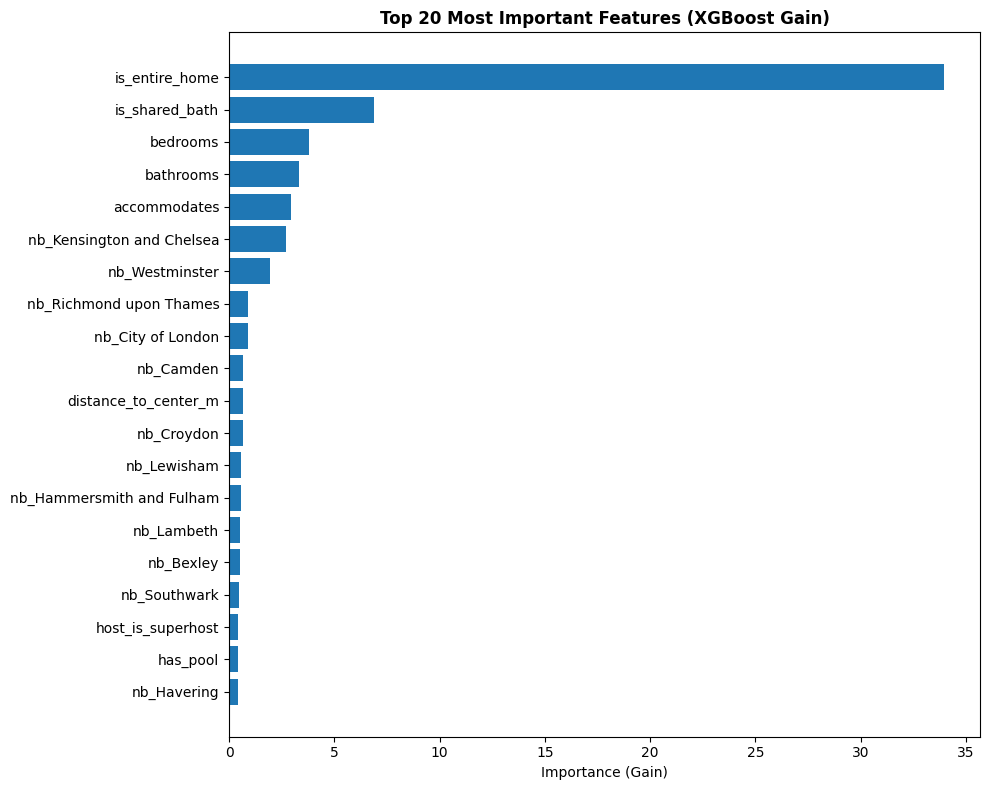

In [43]:
booster = final_xgb.get_booster()
booster.feature_names = feature_names
gain = pd.Series(booster.get_score(importance_type='gain')).sort_values().tail(20)
with plt.rc_context(RC_PLOT):
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.barh(gain.index, gain.values, color='#1f77b4')
    ax.set_xlabel('Importance (Gain)')
    ax.set_title('Top 20 Most Important Features (XGBoost Gain)', fontweight='bold')
    plt.tight_layout(); plt.show()

### 9.2 Where the model works and fails - real listings

Concrete test listings unseen by the model. Three well-predicted cases (across the price range) and three strongly deviating cases. The following cell is self-contained (reloads the listing names, identical preparation, room type coded once).


In [44]:
# Self-contained example evaluation (reloads names; identical preparation, dedup)
_cols=['name','host_is_superhost','latitude','longitude','room_type','accommodates','bathrooms','bathrooms_text','bedrooms','amenities','price','review_scores_location','availability_365','neighbourhood_cleansed','calculated_host_listings_count','estimated_occupancy_l365d','host_has_profile_pic']
_df=pd.read_csv('data.csv')[_cols].dropna(subset=[c for c in _cols if c!='name'])
_nb=pd.get_dummies(_df['neighbourhood_cleansed'],prefix='nb',dtype=int); _df=pd.concat([_df,_nb],axis=1).drop(columns='neighbourhood_cleansed')
_R=6371000.0; _clat,_clon=51.509865,-0.118092
_p1=np.radians(_df['latitude']); _dp=np.radians(_clat-_df['latitude']); _dl=np.radians(_clon-_df['longitude'])
_a=np.sin(_dp/2)**2+np.cos(_p1)*np.cos(np.radians(_clat))*np.sin(_dl/2)**2
_df['distance_to_center_m']=(_R*2*np.arctan2(np.sqrt(_a),np.sqrt(1-_a))).round()
_df['host_is_superhost']=(_df['host_is_superhost']=='t').astype(int); _df['host_has_profile_pic']=(_df['host_has_profile_pic']=='t').astype(int)
_df['is_professional_host']=(_df['calculated_host_listings_count']>=10).astype(int)
_df['is_entire_home']=(_df['room_type']=='Entire home/apt').astype(int)
_df['_hotel']=(_df['room_type']=='Hotel room').astype(int); _df['_shared']=(_df['room_type']=='Shared room').astype(int)
_df=_df[(_df['_hotel']==0)&(_df['_shared']==0)]
_df['price_dollar']=(_df['price'].str.replace('$','',regex=False).str.replace(',','',regex=False).str.replace('.00','',regex=False).astype(float))
_df['is_shared_bath']=_df['bathrooms_text'].str.contains('shared',case=False,na=False).astype(int)
_df=_df[(_df['price_dollar']>=10)&(_df['price_dollar']<1000)]; _df=_df[_df['bedrooms']<=10]; _df=_df[_df['bathrooms']<=8]; _df=_df[_df['availability_365']>0]
def _pa(v):
    try: return ast.literal_eval(v) if isinstance(v,str) else []
    except Exception: return []
_al=_df['amenities'].apply(_pa); _df['amenity_count']=_al.apply(len)
_df['has_pool']=_al.apply(lambda l:any('pool'in a.lower() for a in l)).astype(int)
_df['has_hot_tub']=_al.apply(lambda l:any('hot tub'in a.lower() or 'jacuzzi'in a.lower() for a in l)).astype(int)
_df['has_bathtub']=_al.apply(lambda l:any('bathtub'in a.lower() for a in l)).astype(int)
_df['has_balcony']=_al.apply(lambda l:any('balcony'in a.lower() or 'patio'in a.lower() for a in l)).astype(int)
_df=_df[_df['amenity_count']>0].reset_index(drop=True)
_drop=['name','room_type','bathrooms_text','amenities','price','_hotel','_shared','latitude','longitude','price_dollar']
_X=_df.drop(columns=_drop); _y=np.log1p(_df['price_dollar'])
_Xtr,_Xte,_ytr,_yte,_ntr,_nte,_ptr,_pte=train_test_split(_X,_y,_df['name'].astype(str),_df['price_dollar'],test_size=0.2,random_state=42)
_m=xgb.XGBRegressor(n_estimators=600,max_depth=6,learning_rate=0.05,subsample=0.9,colsample_bytree=0.9,reg_lambda=1.0,random_state=42,verbosity=0).fit(_Xtr,_ytr)
_sm=np.mean(np.exp(_ytr.values-_m.predict(_Xtr)))
_pred=np.exp(_m.predict(_Xte))*_sm-1
_te=pd.DataFrame({'Listing':_nte.values,'Actual ($)':_pte.values.round(0).astype(int),'Predicted ($)':_pred.round(0).astype(int)})
_te['Error %']=((_te['Predicted ($)']-_te['Actual ($)'])/_te['Actual ($)']*100).round(0).astype(int)
def _pick(keys): return pd.DataFrame([_te[_te['Listing'].str.contains(k,case=False,na=False,regex=False)].iloc[0] for k in keys]).reset_index(drop=True)
print('Well-predicted listings (across the price range):')
display(_pick(['Cozy Comfortable room Clapham','Beautiful sunny one bed flat','Fab family-friendly 5 bedroom home']))
print('Large deviations:')
display(_pick(['Large 2 Bedroom Apt in Hackney','THE QUEENS HOSTEL','PRIME CHELSEA STUDIO']))

Well-predicted listings (across the price range):


,Listing,Actual ($),Predicted ($),Error %
0,Cozy Comfortable room Clapham,58,57,-2
1,Beautiful sunny one bed flat,133,132,-1
2,Fab family-friendly 5 bedroom home - Parsons G...,676,676,0


Large deviations:


,Listing,Actual ($),Predicted ($),Error %
0,Large 2 Bedroom Apt in Hackney,999,176,-82
1,"THE QUEENS HOSTEL , 6 BED MIXED DORM C",19,106,458
2,PRIME CHELSEA STUDIO IN 24HR DOORMAN ART DECO ...,36,162,350


### 9.3 Inside the $999 error - SHAP waterfall

Why does the model predict only ~$180 for the Hackney flat listed at $999? The SHAP waterfall shows: all observable features sum to a normal mid-range level - nothing points to $999 (-> unobserved quality or a fantasy price set by the host).


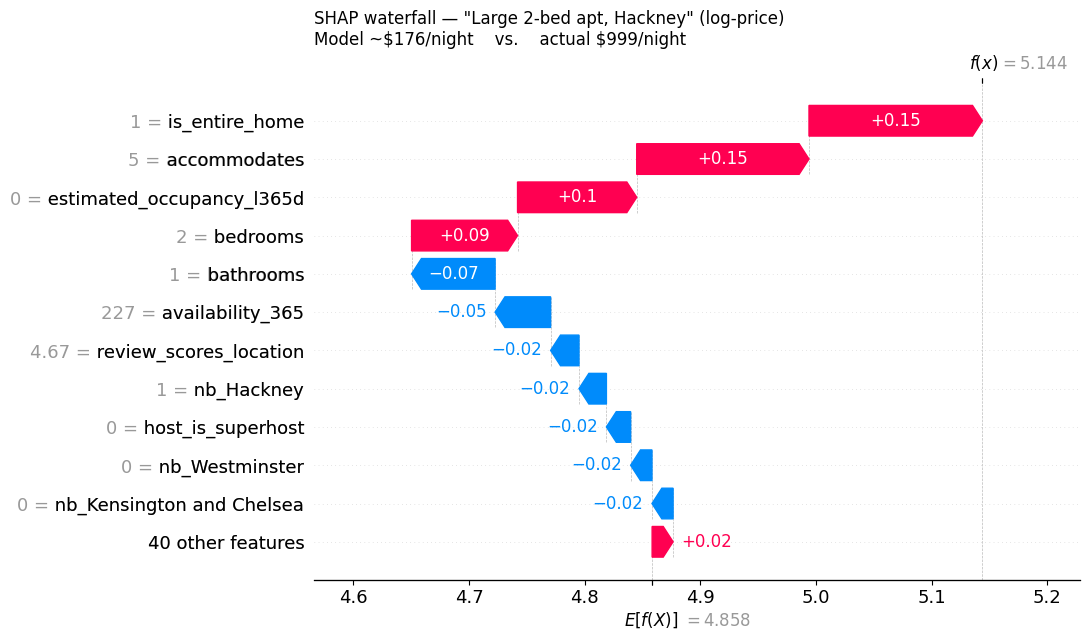

In [45]:
_pos=int(np.where(((_nte.str.contains('Large 2 Bedroom Apt in Hackney',na=False))&(_pte==999)).values)[0][0])
_pred999=float(np.exp(_m.predict(_Xte.iloc[[_pos]]))[0]*_sm-1)
_e=shap.TreeExplainer(_m)(_Xte)[_pos]; _e.feature_names=list(_X.columns)
with plt.rc_context(RC_PLOT):
    shap.plots.waterfall(_e, max_display=12, show=False)
    plt.gcf().set_size_inches(11, 6.5)
    plt.title('SHAP waterfall — "Large 2-bed apt, Hackney" (log-price)\n'
              f'Model ~\\${_pred999:.0f}/night    vs.    actual \\$999/night', fontsize=12, loc='left')
    plt.tight_layout(); plt.show()

## 10. Overview of all features (ordered by influence)

Complete list of all features that entered the models. Three views are shown:

1. **Full list** of all features, sorted by the mean absolute SHAP influence of the final XGBoost model (best model from Section 5).
2. **Grouped, sorted by XGBoost:** the 33 borough dummies aggregated into one row (sum of their |SHAP| values), so that the direct features are not buried under the many borough rows.
3. **Grouped, sorted by OLS:** the same grouped table, ordered by the OLS SHAP influence from Section 4.1.

How to read:
- **|SHAP| XGBoost** is the mean absolute SHAP value on the standardised scale of the boosting model (Section 6); **|SHAP| OLS** is the mean absolute contribution to the log(1+price) prediction of the linear model (Section 4.1). The two columns have different units and are only comparable as a *ranking within* each column.
- The OLS estimation is k−1 coded, so one borough dummy (the reference borough) has no OLS value (`NaN`); the aggregated row skips it when summing.


In [46]:
# Complete feature overview, ordered by influence
# Tree SHAP (XGBoost, Section 6) - mean absolute influence per feature
tree_imp = pd.Series(np.abs(shap_values).mean(axis=0), index=X.columns)

# OLS SHAP (Section 4.1) - on log(1+price); k−1 coded (reference borough missing -> NaN)
ols_imp = shap_ols.abs().mean().reindex(X.columns)

def feature_group(f):
    if f.startswith('nb_'):
        return 'borough dummy'
    if f.startswith('has_') or f.startswith('is_') or f == 'host_is_superhost':
        return 'binary'
    return 'numeric'

feat_tbl = pd.DataFrame({
    'Feature':        X.columns,
    'Type':           [feature_group(f) for f in X.columns],
    '|SHAP| XGBoost': tree_imp.values.round(4),
    '|SHAP| OLS':     ols_imp.values.round(4),
})

n_nb = sum(c.startswith('nb_') for c in X.columns)
print(f'Number of features in the ML model: {X.shape[1]}  '
      f'({n_nb} borough dummies, {X.shape[1] - n_nb} direct features)')
print('Features per type:', feat_tbl['Type'].value_counts().to_dict())

# ---- (a) Full list of all features, sorted by XGBoost influence ----
full_xgb = feat_tbl.sort_values('|SHAP| XGBoost', ascending=False).reset_index(drop=True)
full_xgb.index = full_xgb.index + 1   # rank starting at 1
print('\n=== Full feature list (sorted by |SHAP| XGBoost) ===')
with pd.option_context('display.max_rows', None):
    display(full_xgb)

# ---- Grouped view: aggregate the 33 borough dummies into one row ----
nb_col = tree_imp.index.str.startswith('nb_')
direct = feat_tbl[feat_tbl['Type'] != 'borough dummy'].copy()
nb_row = pd.DataFrame([{
    'Feature':        f'Borough (aggregated, {n_nb} boroughs)',
    'Type':           'borough dummy',
    '|SHAP| XGBoost': round(float(tree_imp[nb_col].sum()), 4),
    '|SHAP| OLS':     round(float(ols_imp[nb_col].sum()), 4),
}])
grouped = pd.concat([direct, nb_row], ignore_index=True)

# ---- (b) Grouped, both sort orders ----
g_xgb = grouped.sort_values('|SHAP| XGBoost', ascending=False).reset_index(drop=True)
g_xgb.index = g_xgb.index + 1
g_ols = grouped.sort_values('|SHAP| OLS', ascending=False).reset_index(drop=True)
g_ols.index = g_ols.index + 1

print('\n=== Grouped (boroughs aggregated), sorted by |SHAP| XGBoost ===')
display(g_xgb)
print('\n=== Grouped (boroughs aggregated), sorted by |SHAP| OLS ===')
display(g_ols)

Number of features in the ML model: 51  (33 borough dummies, 18 direct features)
Features per type: {'borough dummy': 33, 'numeric': 10, 'binary': 8}

=== Full feature list (sorted by |SHAP| XGBoost) ===


,Feature,Type,|SHAP| XGBoost,|SHAP| OLS
1,is_entire_home,binary,0.2328,0.1935
2,accommodates,numeric,0.1387,0.1096
3,distance_to_center_m,numeric,0.1364,0.1777
4,bedrooms,numeric,0.1002,0.0982
5,bathrooms,numeric,0.0734,0.0478
6,review_scores_location,numeric,0.0623,0.0257
7,is_shared_bath,binary,0.0576,0.0790
8,availability_365,numeric,0.0517,0.0492
9,estimated_occupancy_l365d,numeric,0.0507,0.0737
10,amenity_count,numeric,0.0329,0.0216



=== Grouped (boroughs aggregated), sorted by |SHAP| XGBoost ===


,Feature,Type,|SHAP| XGBoost,|SHAP| OLS
1,is_entire_home,binary,0.2328,0.1935
2,accommodates,numeric,0.1387,0.1096
3,distance_to_center_m,numeric,0.1364,0.1777
4,"Borough (aggregated, 33 boroughs)",borough dummy,0.1353,0.2508
5,bedrooms,numeric,0.1002,0.0982
6,bathrooms,numeric,0.0734,0.0478
7,review_scores_location,numeric,0.0623,0.0257
8,is_shared_bath,binary,0.0576,0.0790
9,availability_365,numeric,0.0517,0.0492
10,estimated_occupancy_l365d,numeric,0.0507,0.0737



=== Grouped (boroughs aggregated), sorted by |SHAP| OLS ===


,Feature,Type,|SHAP| XGBoost,|SHAP| OLS
1,"Borough (aggregated, 33 boroughs)",borough dummy,0.1353,0.2508
2,is_entire_home,binary,0.2328,0.1935
3,distance_to_center_m,numeric,0.1364,0.1777
4,accommodates,numeric,0.1387,0.1096
5,bedrooms,numeric,0.1002,0.0982
6,is_shared_bath,binary,0.0576,0.0790
7,estimated_occupancy_l365d,numeric,0.0507,0.0737
8,availability_365,numeric,0.0517,0.0492
9,bathrooms,numeric,0.0734,0.0478
10,host_is_superhost,binary,0.0303,0.0472
